# Прогнозирование температуры звезды

Вам пришла задача от обсерватории «Небо на ладони»: придумать, как с помощью нейросети определять температуру на поверхности обнаруженных звёзд. Обычно для расчёта температуры учёные пользуются следующими методами:

    Закон смещения Вина.
    Закон Стефана-Больцмана.
    Спектральный анализ.

Каждый из них имеет плюсы и минусы. Обсерватория хочет внедрить технологии машинного обучения для предсказания температуры звёзд, надеясь, что этот метод будет наиболее точным и удобным.

**Описание задачи:**

В этом самостоятельном проекте вам необходимо разработать нейронную сеть, которая поможет предсказывать абсолютную температуру на поверхности звезды.

## Загрузка данных

Объявим необходмые библиотеки, загрузим датафреймы и выведем их основную информацию:

In [1]:
!pip install -U ydata-profiling
!pip install phik
!pip install --upgrade numpy scikit-learn datashader
!pip install pandas==1.3.5
!pip install matplotlib==3.5.3 ydata-profiling==4.10.0
!pip install --upgrade seaborn
!pip install pandas==3.1.2
%matplotlib inline

     |████████████████████████████████| 356 kB 1.0 MB/s eta 0:00:01
     |████████████████████████████████| 104 kB 2.3 MB/s eta 0:00:01
     |████████████████████████████████| 434 kB 2.2 MB/s eta 0:00:01
     |████████████████████████████████| 513 kB 60.9 MB/s eta 0:00:01
     |████████████████████████████████| 8.3 MB 2.0 MB/s eta 0:00:01��███████████▋       | 6.4 MB 2.0 MB/s eta 0:00:01
     |████████████████████████████████| 296 kB 94.0 MB/s eta 0:00:01
     |████████████████████████████████| 4.5 MB 87.8 MB/s eta 0:00:01███▍                  | 1.9 MB 87.8 MB/s eta 0:00:01
     |████████████████████████████████| 19.5 MB 262 kB/s  eta 0:00:01██████████▏                  | 8.0 MB 83.3 MB/s eta 0:00:01     |██████████████████████▌         | 13.7 MB 83.3 MB/s eta 0:00:01�███████▋| 19.3 MB 83.3 MB/s eta 0:00:01
     |████████████████████████████████| 4.6 MB 81.1 MB/s eta 0:00:01
     |████████████████████████████████| 321 kB 90.2 MB/s eta 0:00:01
     |████████████████████████████████| 3.7

In [2]:
import random
import pandas as pd
import os
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns

import ydata_profiling as pp
import plotly.graph_objects as go

from phik import phik_matrix
from phik.report import plot_correlation_matrix

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import torch
import torch.nn as nn
import torch.optim as optim

import itertools

from math import ceil

SEED = 3
random.seed(3)
np.random.seed(3)
torch.manual_seed(3)
torch.use_deterministic_algorithms(True)

In [3]:
pth = '/datasets/6_class.csv'

if os.path.exists(pth):
    df = pd.read_csv(pth, index_col='Unnamed: 0')
    display(df)
    display(df.info())
else:
    print('Путь к первому датафрейму не найден')

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color
0,3068,0.002400,0.1700,16.12,0,Red
1,3042,0.000500,0.1542,16.60,0,Red
2,2600,0.000300,0.1020,18.70,0,Red
3,2800,0.000200,0.1600,16.65,0,Red
4,1939,0.000138,0.1030,20.06,0,Red
...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,5,Blue
236,30839,834042.000000,1194.0000,-10.63,5,Blue
237,8829,537493.000000,1423.0000,-10.73,5,White
238,9235,404940.000000,1112.0000,-11.23,5,White


<class 'pandas.core.frame.DataFrame'>
Index: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature (K)         240 non-null    int64  
 1   Luminosity(L/Lo)        240 non-null    float64
 2   Radius(R/Ro)            240 non-null    float64
 3   Absolute magnitude(Mv)  240 non-null    float64
 4   Star type               240 non-null    int64  
 5   Star color              240 non-null    object 
dtypes: float64(3), int64(2), object(1)
memory usage: 13.1+ KB


None

Детальнее изучим данные с помощью EDA.

In [4]:
#проведение EDA
pp.ProfileReport(df, vars={'num': {'low_categorical_threshold': 7}})

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Данные загружены, соответствуют описанию. Приведём имена столбцов к стандартному виду. 

In [5]:
df.rename(
    columns={
        'Temperature (K)': 'temp_k', 'Luminosity(L/Lo)': 'lum', 'Radius(R/Ro)': 'rad_r', 
        'Absolute magnitude(Mv)': 'abs_magn', 'Star type': 'star_type','Star color': 'star_color'
    }, 
    inplace=True
)

## Предобработка и анализ данных

,temp_k
count,240.00
mean,10497.46
median,5776.00
max,40000.00
min,1939.00
10th_percentile,2935.00
25th_percentile,3344.25
75th_percentile,15055.50
90th_percentile,24667.00


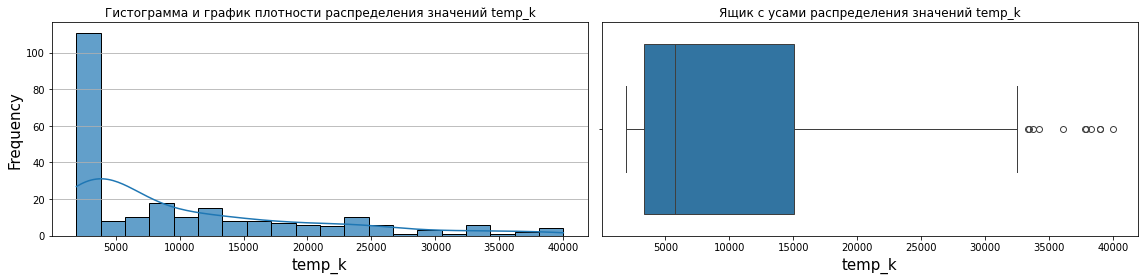

,lum
count,240.00
mean,107188.36
median,0.07
max,849420.00
min,0.00
10th_percentile,0.00
25th_percentile,0.00
75th_percentile,198050.00
90th_percentile,333268.00


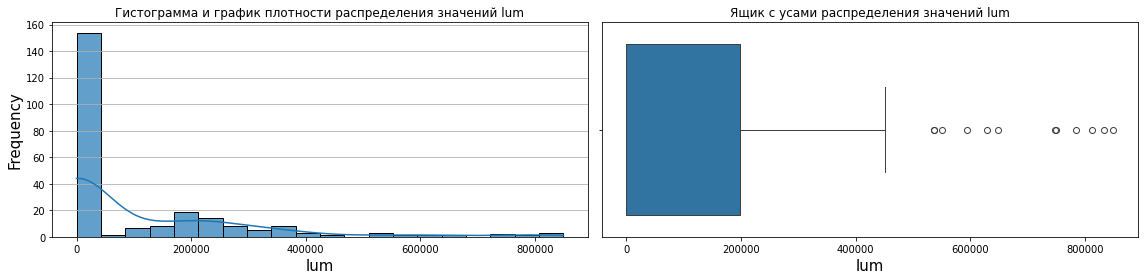

,rad_r
count,240.00
mean,237.16
median,0.76
max,1948.50
min,0.01
10th_percentile,0.01
25th_percentile,0.10
75th_percentile,42.75
90th_percentile,1315.90


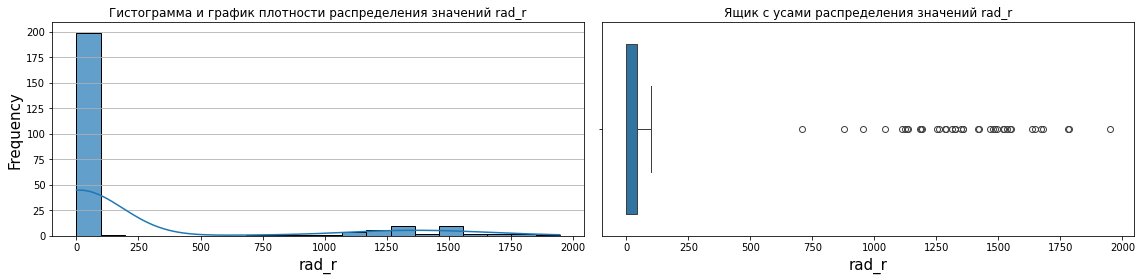

,abs_magn
count,240.00
mean,4.38
median,8.31
max,20.06
min,-11.92
10th_percentile,-9.20
25th_percentile,-6.23
75th_percentile,13.70
90th_percentile,16.96


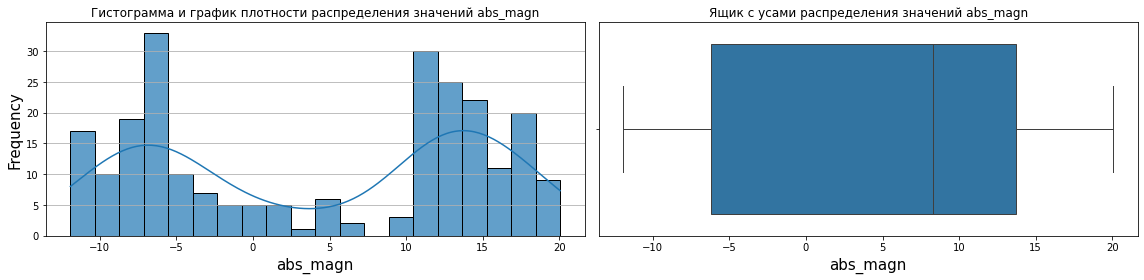

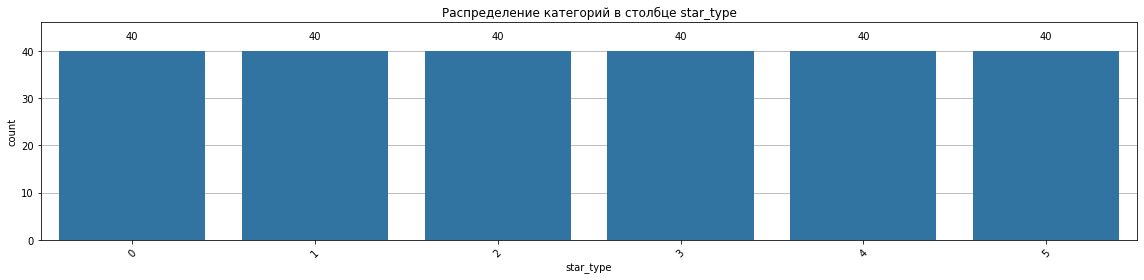

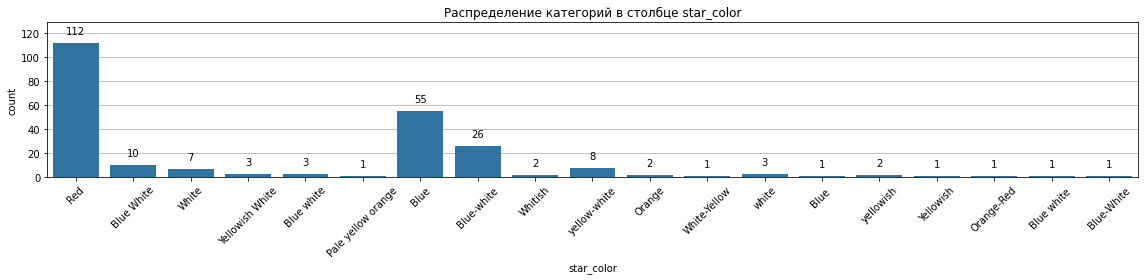

In [6]:
def histogram(data):
    
    '''
        Функция вывода таблицы параметров агрегации, построения графиков распределения значений и ящика с усами
    для каждого столбца с численными данными. В случае, если в данных присутствуют цифровые категориальные значения,
    условием

        if col != 'id' and data[col].nunique() > 19:

    можно вычленить данные столбцы и построить для них диаграммы countplot.

        Также есть опциональный цикл для работы с данными формата "datetime".

        Для текстовых категориальных столбцов создан отдельный цикл. В нём строятся круговые диаграммы,
    выводятся уникальные значения и их доля. Не рационален в случае большого количества уникальных значений категорий.
        Если значений слишком много, и круговая диаграмма становится нечитаемой, 
        можно модернизировать под отображение график sns.countplot().

        Если в данных слишком большие выбросы, можно воспользоваться переменной filtered_data.
        
        Для анализа данных формата "object" предусмотрены круговые диаграммы значений. 
        
        
        Аргументы:
    data : pd.DataFrame

        Возвращаемое значение:
    None

    '''
    
    rows = data.select_dtypes(include=['float64', 'int64', 'object']).columns
    
    for i, col in enumerate(rows):
        if col != 'id' and data[col].nunique() > 20:
            f, ax = plt.subplots(1, 2, figsize=(16, 4))
            display(round(data[col].agg({'count': 'count', 'mean': 'mean', 'median': 'median', \
                                         'max': 'max', 'min': 'min', '10th_percentile': lambda x: x.quantile(0.1),\
                                         '25th_percentile': lambda x: x.quantile(0.25), \
                                         '75th_percentile': lambda x: x.quantile(0.75), \
                                         '90th_percentile': lambda x: x.quantile(0.9)}), 2).to_frame())
            filtered_data = data[data[col] <= data[col].quantile(0.8)]
            #sns.histplot(x=filtered_data[col], kde= True, bins=20, multiple='stack', ax = ax[0], alpha=0.7)
            sns.histplot(x=data[col], kde= True, bins=20, multiple='stack', ax = ax[0], alpha=0.7)
            sns.boxplot(x=data[col], ax = ax[1])
            ax[0].set_title('Гистограмма и график плотности распределения значений {}'.format(col))
            ax[0].set_xlabel(col, fontsize=15)
            ax[0].set_ylabel('Frequency', fontsize=15)
            ax[0].grid(axis='y')
            ax[1].set_title('Ящик с усами распределения значений {}'.format(col))
            ax[1].set_xlabel(col, fontsize=15)
            plt.tight_layout()
            plt.show()
            #plt.close(f)
        elif col != 'id':
            plt.figure(figsize=(16, 4))
            ax = sns.countplot(x=data[col])
            plt.grid(axis='y')
            plt.gca().set_axisbelow(True)
            plt.title('Распределение категорий в столбце {}'.format(col))
            plt.xticks(rotation=45)
            plt.tight_layout()
            for p in ax.patches:
                ax.annotate(f'{int(p.get_height())}', \
                            (p.get_x() + p.get_width() / 2., p.get_height() + 0.05 * max(data[col].value_counts())), 
                            ha='center', va='bottom', fontsize=10, color='black', rotation=0)
            max_height = max(data[col].value_counts())
            plt.ylim(0, max_height * 1.15)
            plt.show()
            #plt.close()

    
'''
    for col in data.select_dtypes(include='datetime').columns:
        display(data[col].agg(['count', 'max', 'min']).to_frame())
        f, ax = plt.subplots(1, 2, figsize=(16, 4))
        filtered_data = data[data[col] <= pd.to_datetime('2018-01-01')]
        sns.histplot(x=filtered_data[col], kde=True, bins=30, multiple='stack', ax = ax[0], alpha=0.7)
        #sns.histplot(x=data[col], kde=True, bins=30, multiple='stack', ax = ax[0], alpha=0.7)
        sns.boxplot(x=data[col], ax = ax[1])
        ax[0].set_title('Гистограмма и график плотности распределения значений {}'.format(col))
        ax[0].set_xlabel(col, fontsize=15)
        ax[0].set_ylabel('Frequency', fontsize=15)
        ax[0].grid(axis='y')
        ax[1].set_title('Ящик с усами распределения значений {}'.format(col))
        ax[1].set_xlabel(col, fontsize=15)
        plt.tight_layout()
        plt.show()

    for col in data.select_dtypes(include='object').columns:
        plt.pie(x=data[col].value_counts(), labels = data[col].value_counts().index, autopct='%1.1f%%')
        plt.title('Диаграмма значений столбца {}'.format(col))
        plt.show()
'''
histogram(df)


### Промежуточный вывод:

По столбцам датафрейма наблюдается одностороннее нормальное распределение данных с большим выбросом слева. По столбцу `abs_magn` видно распределение с двумя пиками. По графикам ящика с усами выделяется большое количество выбросов. Это можно объяснить несколькими предположениями:

* данных мало - выборка представлена всего лишь 240 значениями, такого количества недостаточно для формирования правильного распределения;
* типов звёзд `star_type` представлено равное количество - возможно, каждая группа своими значениями "перетягивает одеяло на себя" и из-за различности параметров представительниц каждой группы нормальное распределение не получается.

Также наблюдаются неявные дубликаты в столбце `star_color`. Исправим их, после этого попробуем сформировать графики для каждой группы `star_type`.

In [7]:
df['star_color'].unique()

array(['Red', 'Blue White', 'White', 'Yellowish White', 'Blue white',
       'Pale yellow orange', 'Blue', 'Blue-white', 'Whitish',
       'yellow-white', 'Orange', 'White-Yellow', 'white', 'Blue ',
       'yellowish', 'Yellowish', 'Orange-Red', 'Blue white ',
       'Blue-White'], dtype=object)

In [8]:
df['star_color'] = (df['star_color']
                     .str.lower()                      # Приведение к нижнему регистру
                     .str.strip()                      # Удаление пробелов в начале и в конце строки
                     .str.replace(' ', '_')            # Замена пробелов в середине строки на нижнее подчеркивание
                     .str.replace('-', '_'))           # Замена дефисов на нижнее подчеркивание

star_type 0 (Коричневые карлики)


,temp_k
count,40.00
mean,2997.95
median,2935.00
max,3531.00
min,1939.00
10th_percentile,2648.70
25th_percentile,2812.75
75th_percentile,3242.50
90th_percentile,3456.10


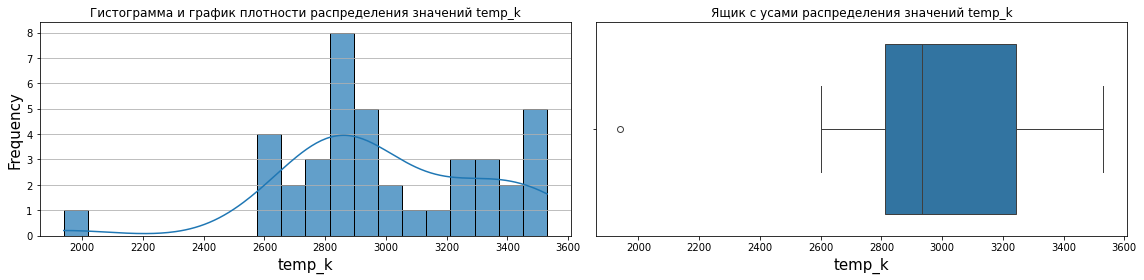

,lum
count,40.00
mean,0.00
median,0.00
max,0.01
min,0.00
10th_percentile,0.00
25th_percentile,0.00
75th_percentile,0.00
90th_percentile,0.00


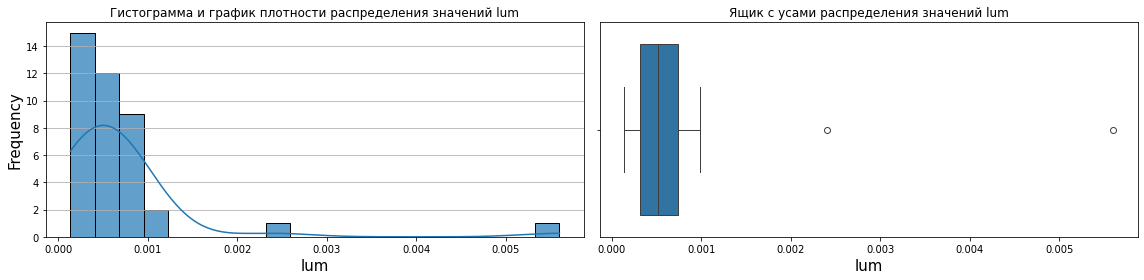

,rad_r
count,40.00
mean,0.11
median,0.11
max,0.19
min,0.06
10th_percentile,0.09
25th_percentile,0.09
75th_percentile,0.12
90th_percentile,0.13


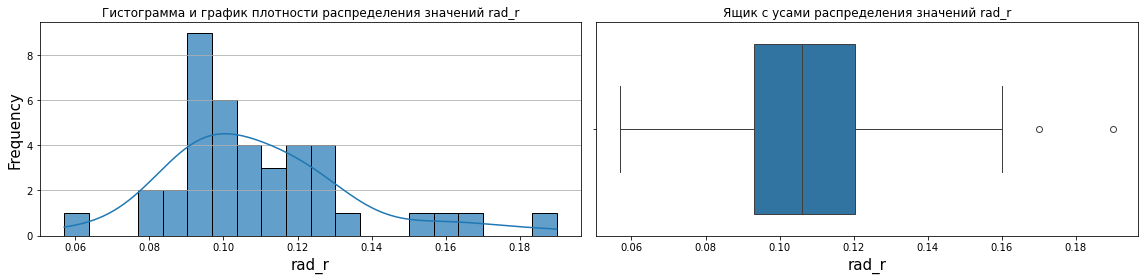

,abs_magn
count,40.00
mean,17.56
median,17.14
max,20.06
min,16.05
10th_percentile,16.23
25th_percentile,16.70
75th_percentile,18.35
90th_percentile,19.57


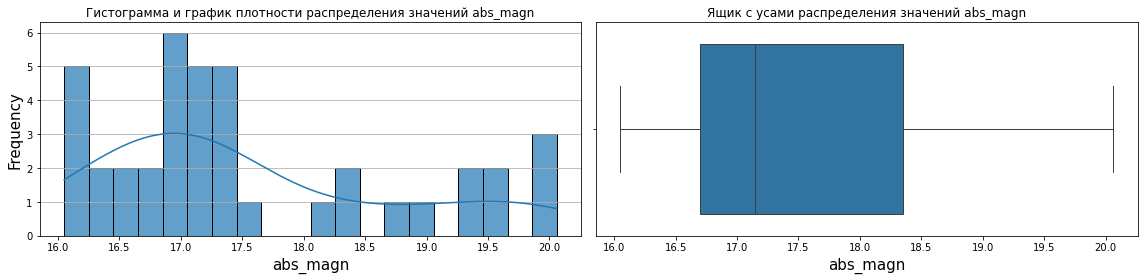

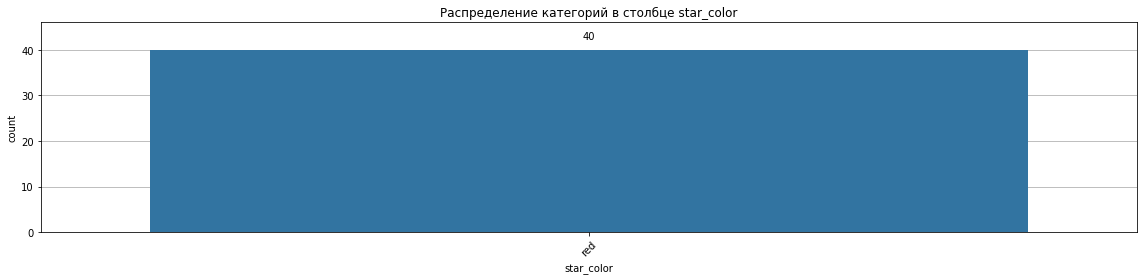


star_type 1 (Красные карлики)


,temp_k
count,40.00
mean,3283.82
median,3314.00
max,3692.00
min,2621.00
10th_percentile,2979.10
25th_percentile,3132.75
75th_percentile,3527.50
90th_percentile,3600.70


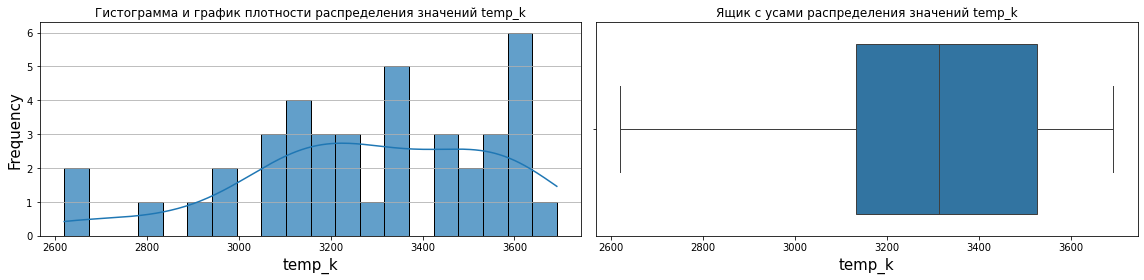

,lum
count,40.00
mean,0.01
median,0.00
max,0.04
min,0.00
10th_percentile,0.00
25th_percentile,0.00
75th_percentile,0.01
90th_percentile,0.01


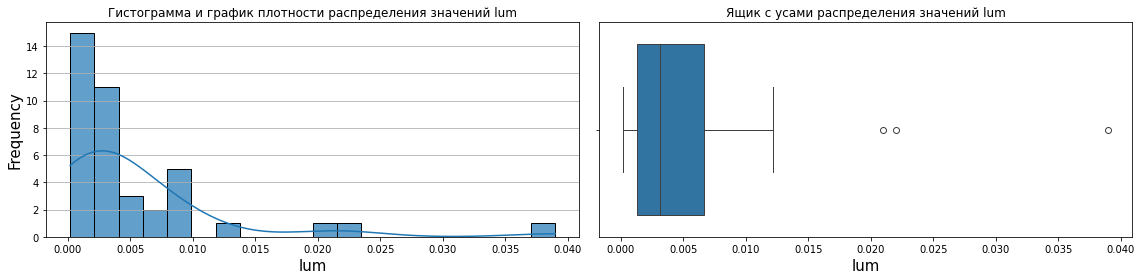

,rad_r
count,40.00
mean,0.35
median,0.34
max,0.73
min,0.10
10th_percentile,0.16
25th_percentile,0.24
75th_percentile,0.41
90th_percentile,0.57


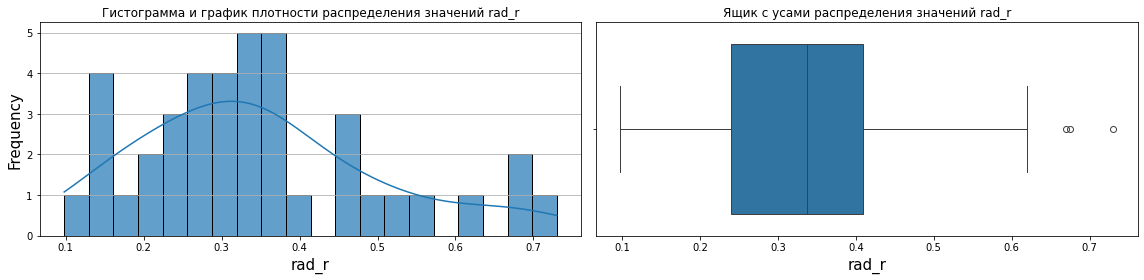

,abs_magn
count,40.00
mean,12.54
median,12.60
max,14.94
min,10.12
10th_percentile,10.73
25th_percentile,11.37
75th_percentile,13.56
90th_percentile,14.37


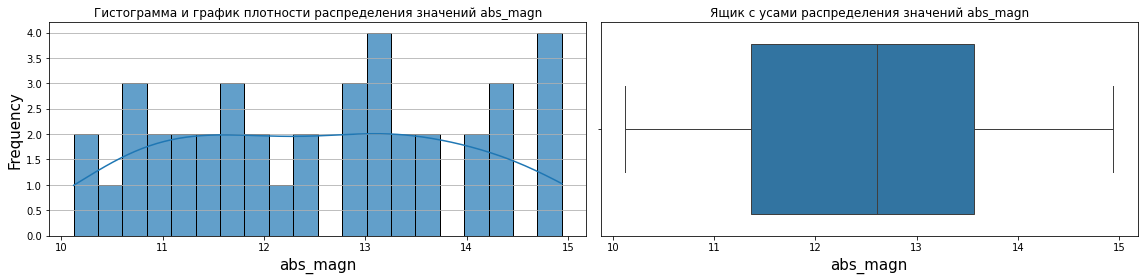

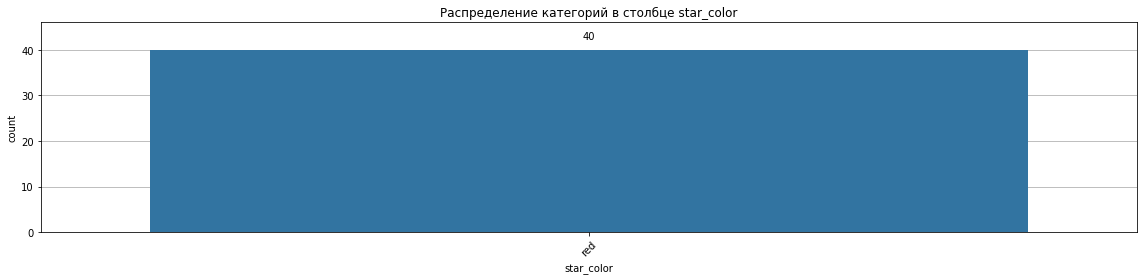


star_type 2 (Белые карлики)


,temp_k
count,40.00
mean,13931.45
median,13380.00
max,25000.00
min,7100.00
10th_percentile,7720.70
25th_percentile,9488.75
75th_percentile,17380.00
90th_percentile,20030.00


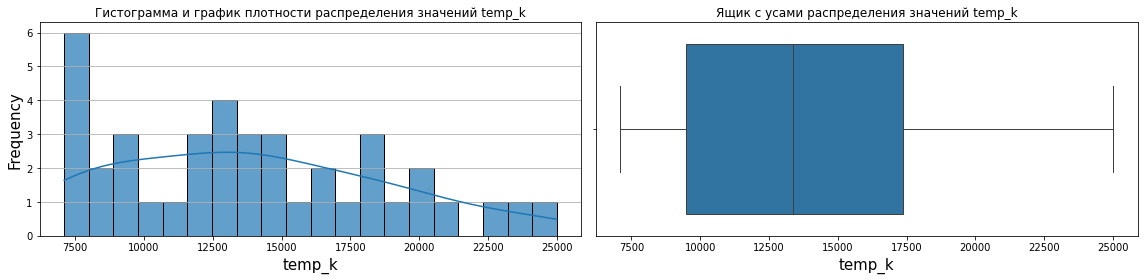

,lum
count,40.00
mean,0.00
median,0.00
max,0.06
min,0.00
10th_percentile,0.00
25th_percentile,0.00
75th_percentile,0.00
90th_percentile,0.00


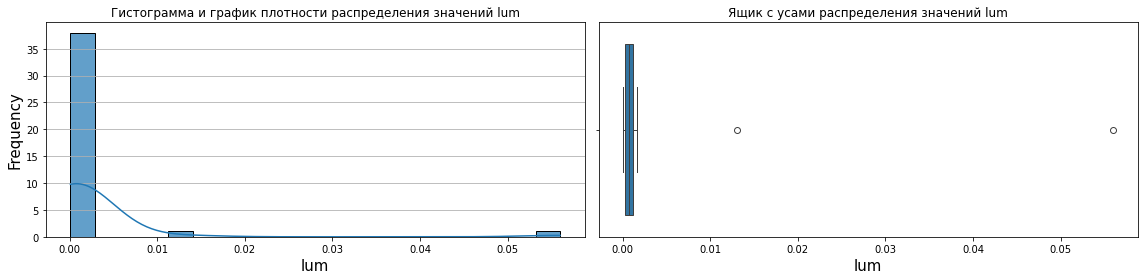

,rad_r
count,40.00
mean,0.01
median,0.01
max,0.02
min,0.01
10th_percentile,0.01
25th_percentile,0.01
75th_percentile,0.01
90th_percentile,0.01


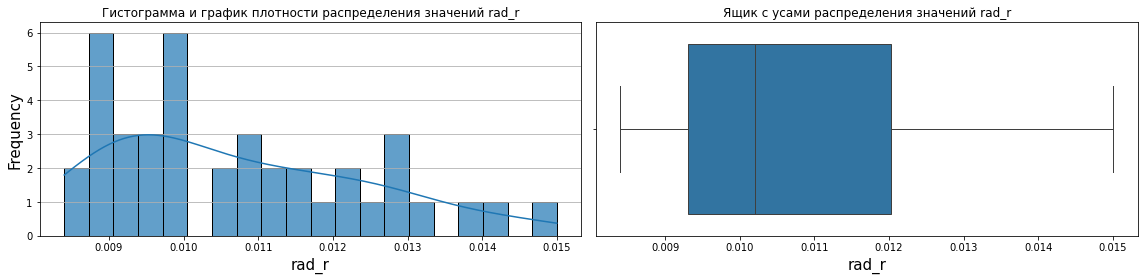

,abs_magn
count,40.00
mean,12.58
median,12.34
max,14.87
min,10.18
10th_percentile,11.22
25th_percentile,11.60
75th_percentile,13.83
90th_percentile,14.25


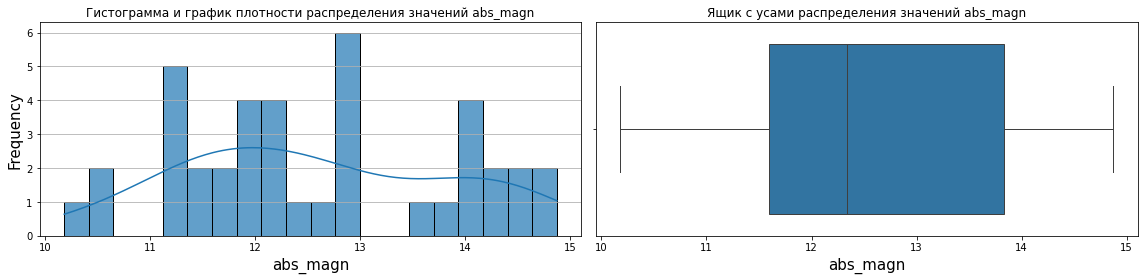

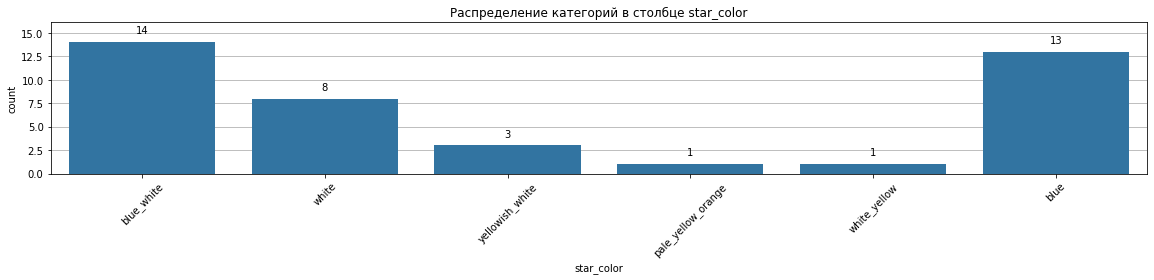


star_type 3 (Звёзды главной последовательности)


,temp_k
count,40.00
mean,16018.00
median,12560.50
max,39000.00
min,4077.00
10th_percentile,5281.20
25th_percentile,7479.25
75th_percentile,23030.00
90th_percentile,32633.00


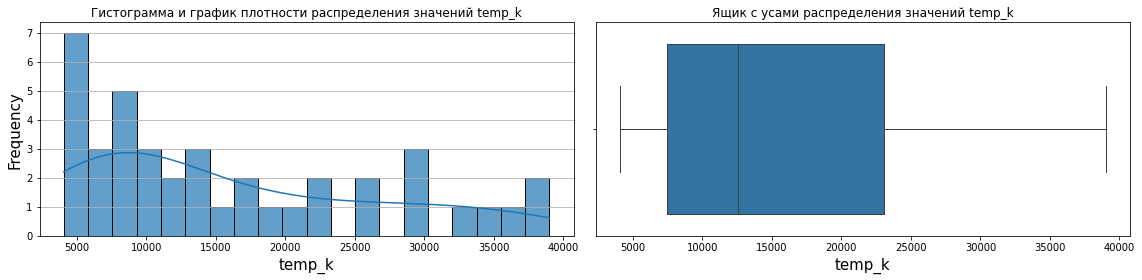

,lum
count,40.00
mean,32067.39
median,738.50
max,204000.00
min,0.08
10th_percentile,0.63
25th_percentile,6.30
75th_percentile,12962.50
90th_percentile,189000.00


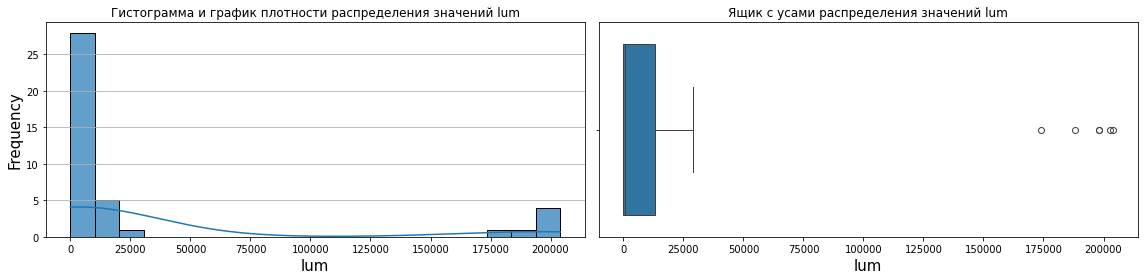

,rad_r
count,40.00
mean,4.43
median,5.71
max,10.60
min,0.80
10th_percentile,0.91
25th_percentile,1.29
75th_percentile,6.37
90th_percentile,6.98


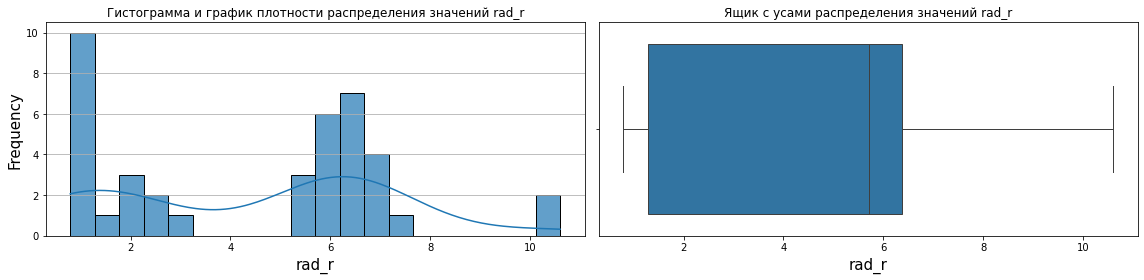

,abs_magn
count,40.00
mean,-0.37
median,-1.18
max,6.51
min,-4.70
10th_percentile,-4.36
25th_percentile,-3.70
75th_percentile,2.42
90th_percentile,5.03


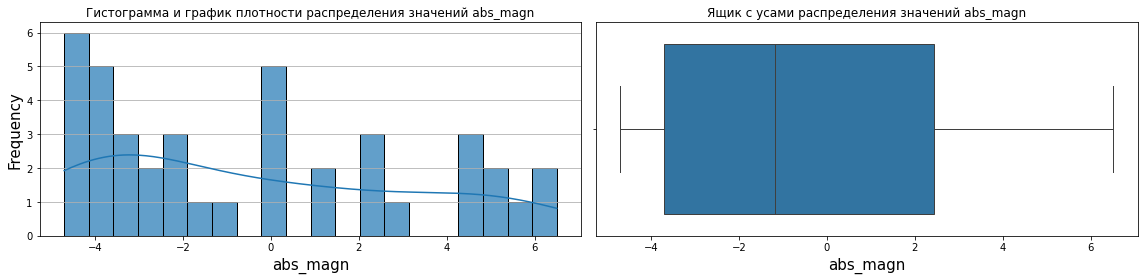

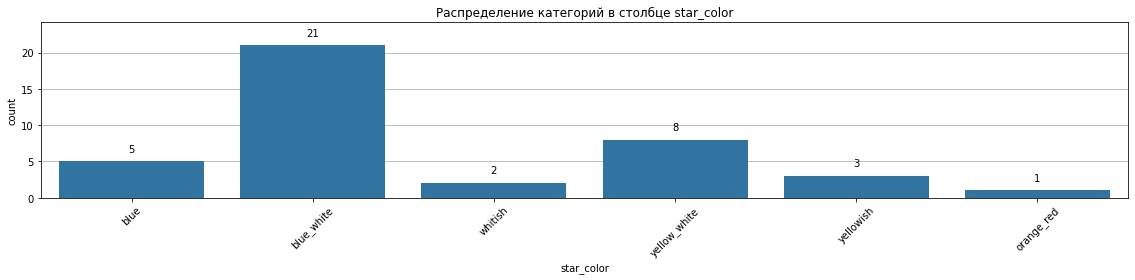


star_type 4 (Сверхгиганты)


,temp_k
count,40.00
mean,15347.85
median,12821.00
max,40000.00
min,3008.00
10th_percentile,3553.10
25th_percentile,6899.50
75th_percentile,23181.25
90th_percentile,27065.70


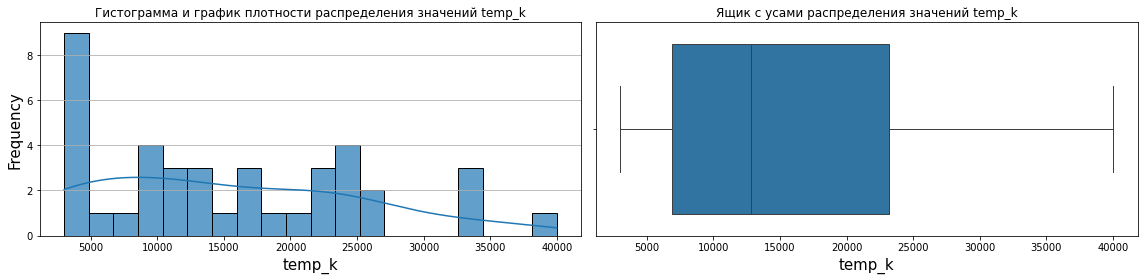

,lum
count,40.00
mean,301816.25
median,242145.00
max,813000.00
min,112000.00
10th_percentile,140900.00
25th_percentile,197250.00
75th_percentile,344160.00
90th_percentile,543077.00


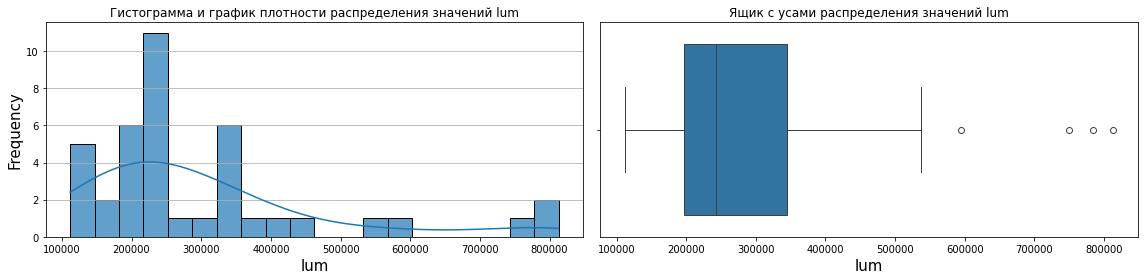

,rad_r
count,40.00
mean,51.15
median,43.50
max,98.00
min,12.00
10th_percentile,18.80
25th_percentile,25.75
75th_percentile,80.25
90th_percentile,88.10


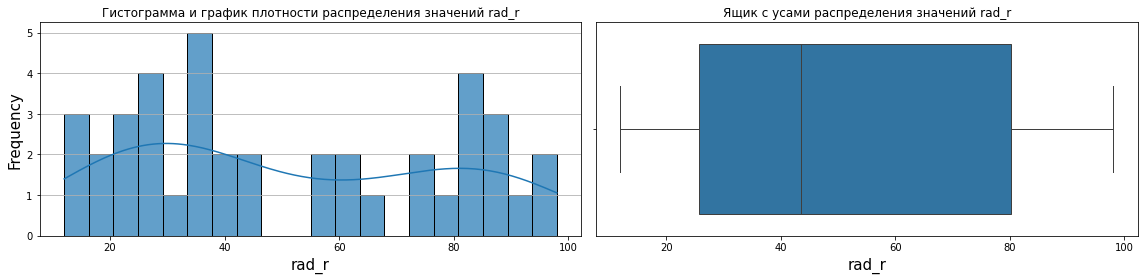

,abs_magn
count,40.00
mean,-6.37
median,-6.24
max,-5.24
min,-7.45
10th_percentile,-7.22
25th_percentile,-6.81
75th_percentile,-5.96
90th_percentile,-5.79


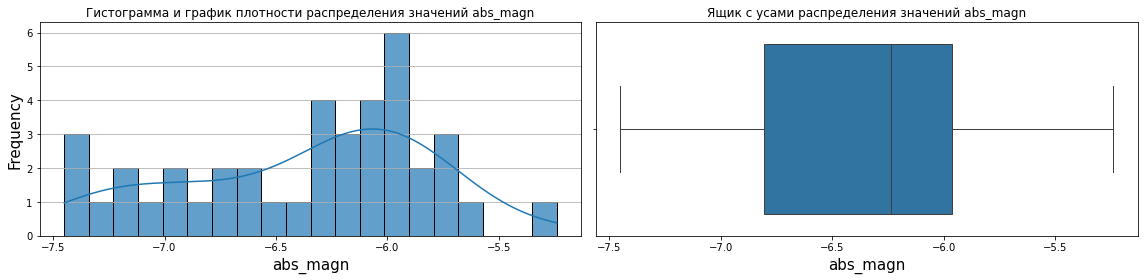

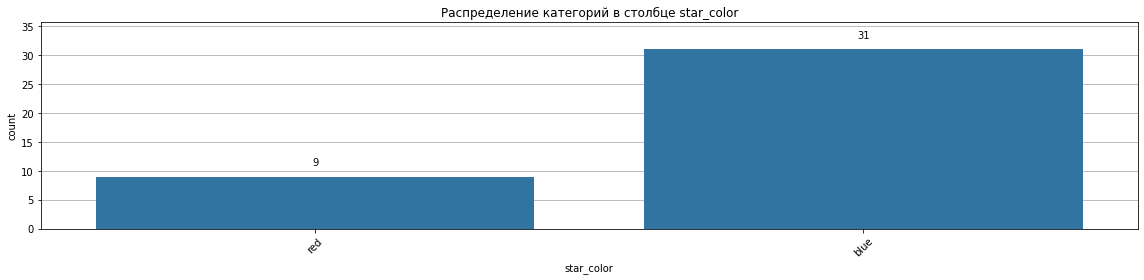


star_type 5 (Гипергиганты)


,temp_k
count,40.00
mean,11405.70
median,3766.00
max,38940.00
min,3399.00
10th_percentile,3486.90
25th_percentile,3603.75
75th_percentile,18976.00
90th_percentile,31004.00


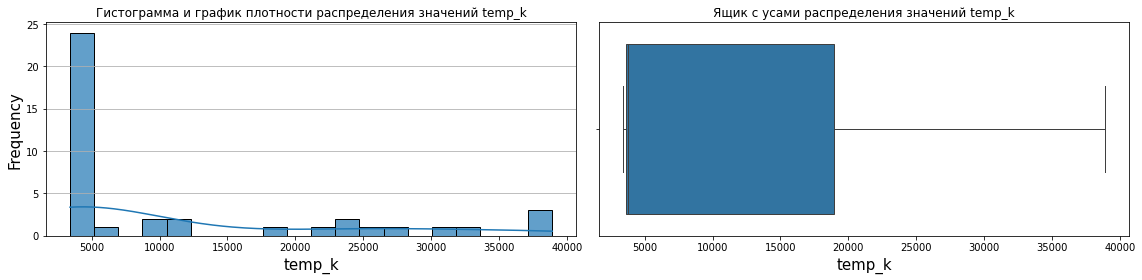

,lum
count,40.00
mean,309246.53
median,266500.00
max,849420.00
min,74000.00
10th_percentile,125400.00
25th_percentile,173000.00
75th_percentile,365957.50
90th_percentile,631843.00


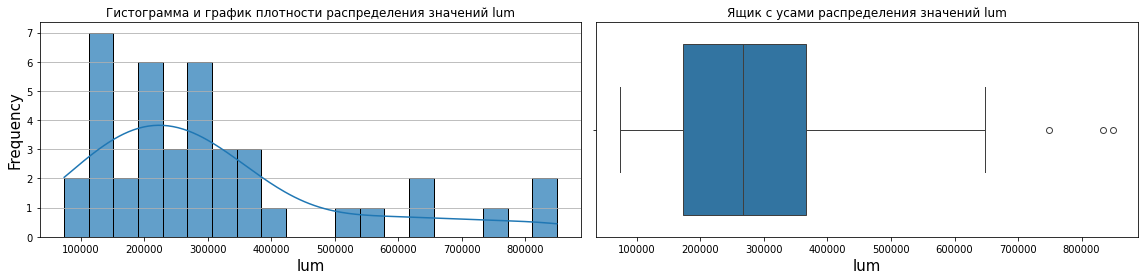

,rad_r
count,40.0
mean,1366.9
median,1352.5
max,1948.5
min,708.9
10th_percentile,1105.3
25th_percentile,1193.0
75th_percentile,1525.0
90th_percentile,1673.6


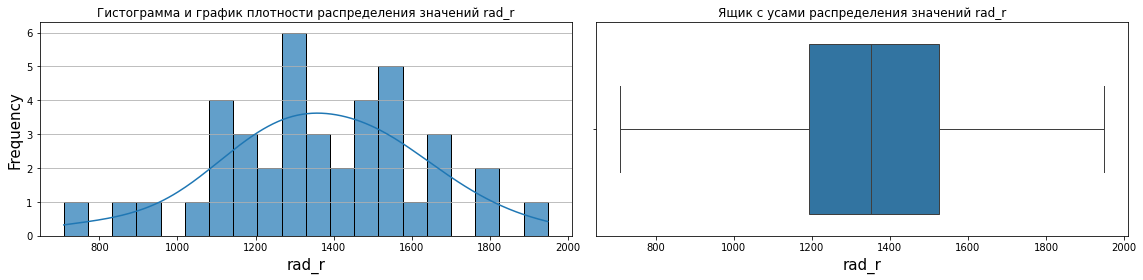

,abs_magn
count,40.00
mean,-9.65
median,-9.91
max,-7.58
min,-11.92
10th_percentile,-11.33
25th_percentile,-10.88
75th_percentile,-8.15
90th_percentile,-7.71


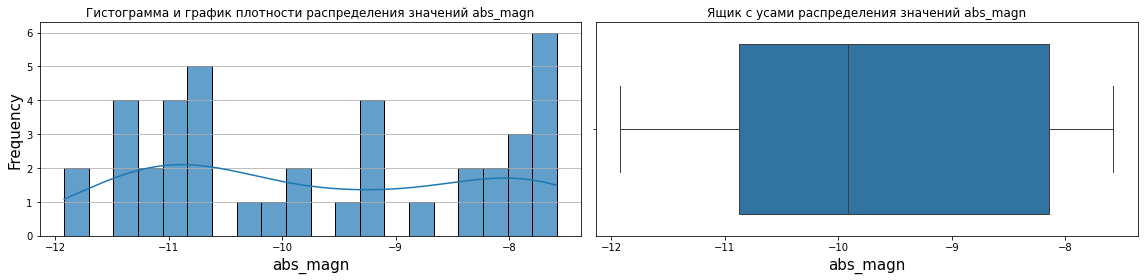

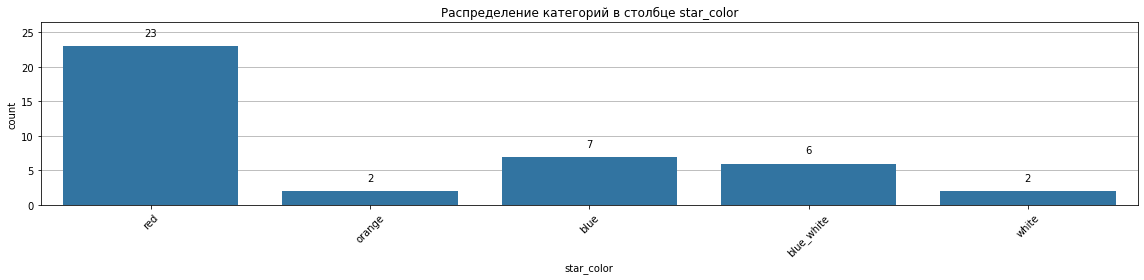

In [9]:
for i in df['star_type'].unique():
    if i == 0:
        c = '(Коричневые карлики)'
    elif i == 1:
        c = '(Красные карлики)'
    elif i == 2:
        c = '(Белые карлики)'
    elif i == 3:
        c = '(Звёзды главной последовательности)'
    elif i == 4:
        c = '(Сверхгиганты)'
    else:
        c = '(Гипергиганты)'
    
    print('star_type', i, c)
    df1 = df.query('star_type == @i').copy()
    df1 = df1.drop(columns='star_type')
    histogram(df1)
    print()

### Промежуточный вывод:

По  новым графикам видно, что распределения стали намного "правильнее", количество выбросов уменьшилось. По данным относительной светимости белых карликов видно большое количество одинаковых данных. Однако, они корректны: средняя светимость белых карликов варьируется, но обычно она составляет приблизительно от 0,01 до 0,1 светимости Солнца.
Также исправлены неявные дубликаты.

Проверим оставшииеся уникальные значения в столбце `star_color` и их количественное распределение: 

In [10]:
df['star_color'].unique()

array(['red', 'blue_white', 'white', 'yellowish_white',
       'pale_yellow_orange', 'blue', 'whitish', 'yellow_white', 'orange',
       'white_yellow', 'yellowish', 'orange_red'], dtype=object)

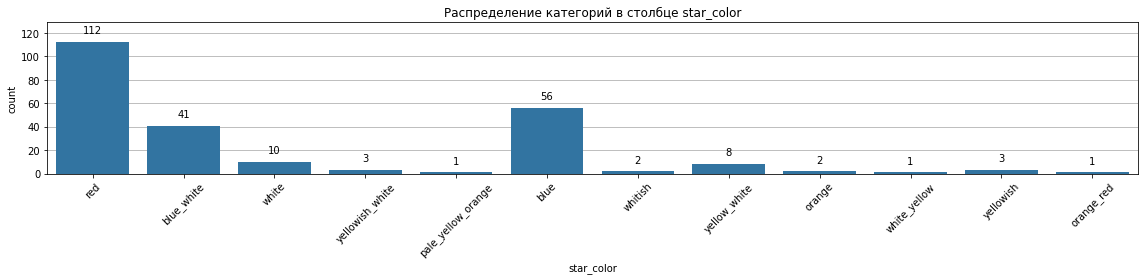

In [11]:
histogram(df[['star_color']])

Заметим, что некоторые цвета как бы "дублируют" друг друга. Например, `yellow_white` и `white_yellow`. С научной точки зрения, они разные, т.к. признак, стоящий последним, преобладает, но не доминирует абсолютно. Однако, такие тонкости могут помешать обучению нейросети и снизить точность предсказания целевого признака. Заменим их.

In [12]:
df['star_color'] = df['star_color'].apply(lambda x: 'yellow_white' if x == 'yellowish_white' else x)
df['star_color'] = df['star_color'].apply(lambda x: 'white' if x == 'whitish' else x)
df['star_color'] = df['star_color'].apply(lambda x: 'yellow_white' if x == 'white_yellow' else x)
df['star_color'] = df['star_color'].apply(lambda x: 'yellow' if x == 'yellowish' else x)
df['star_color'] = df['star_color'].apply(lambda x: 'yellow' if 'orange' in x else x)

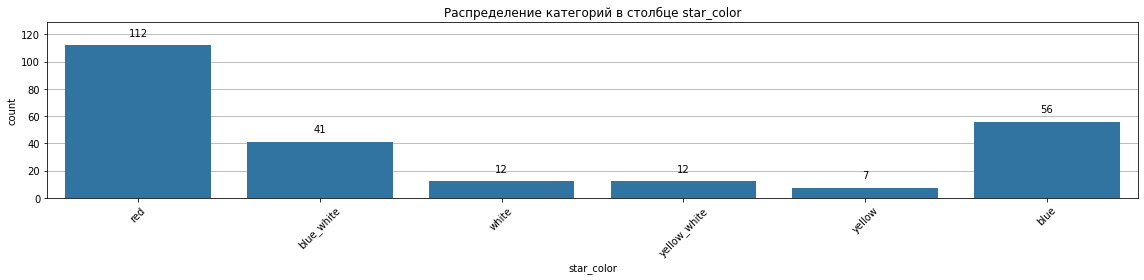

In [13]:
histogram(df[['star_color']])

### Промежуточный вывод:

Оставшиеся неявные дубликаты устранены, количество цветовых категорий уменьшилось.

## Корреляционный анализ

Проведём корреляционный анализ признаков и сделаем выводы о мультиколлинеарности. Также построим матрицу корреляции `phik_matrix()` для проверки данных на утечку.

Также посмотрим равномерность распределения цветовых признаков в разных группах звёзд.

<Figure size 2880x2880 with 0 Axes>

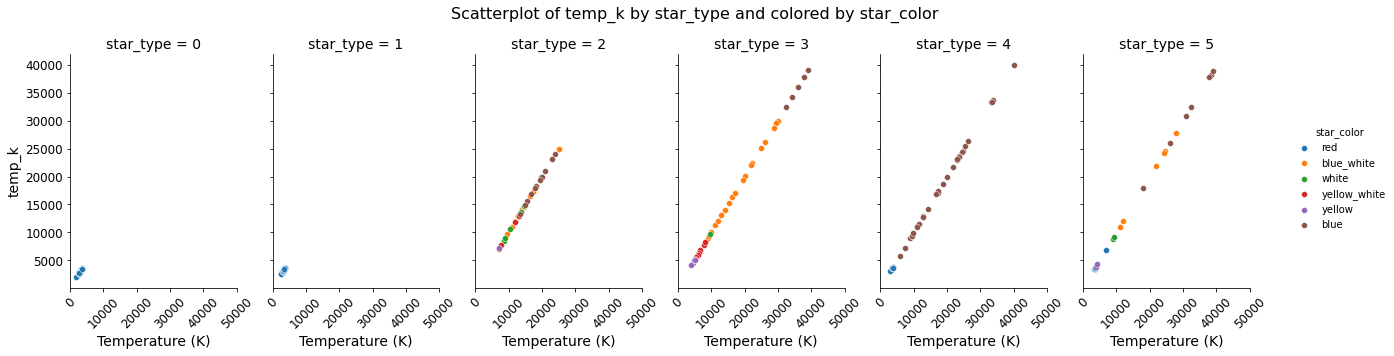

<Figure size 2880x2880 with 0 Axes>

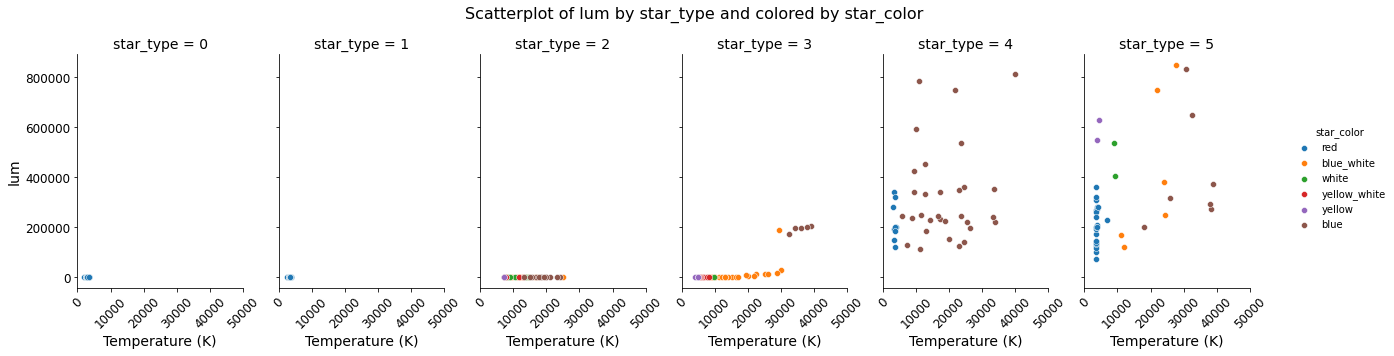

<Figure size 2880x2880 with 0 Axes>

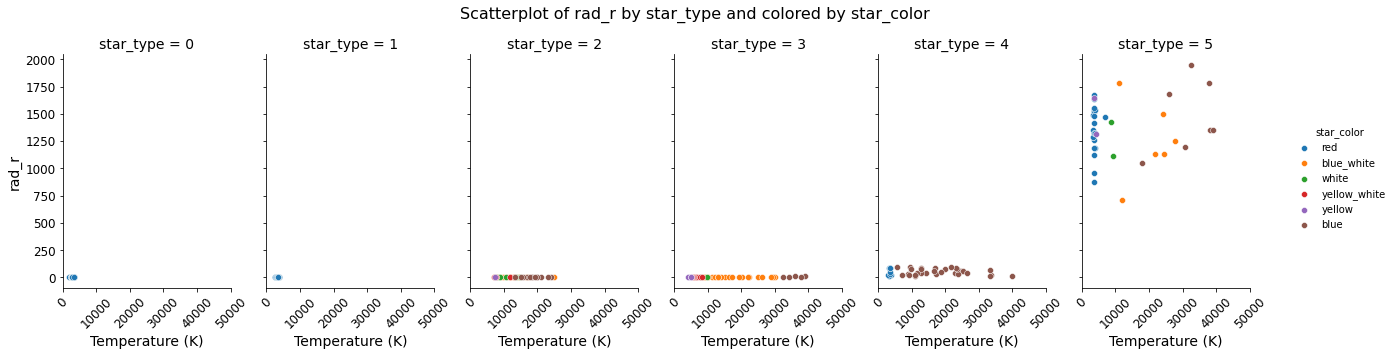

<Figure size 2880x2880 with 0 Axes>

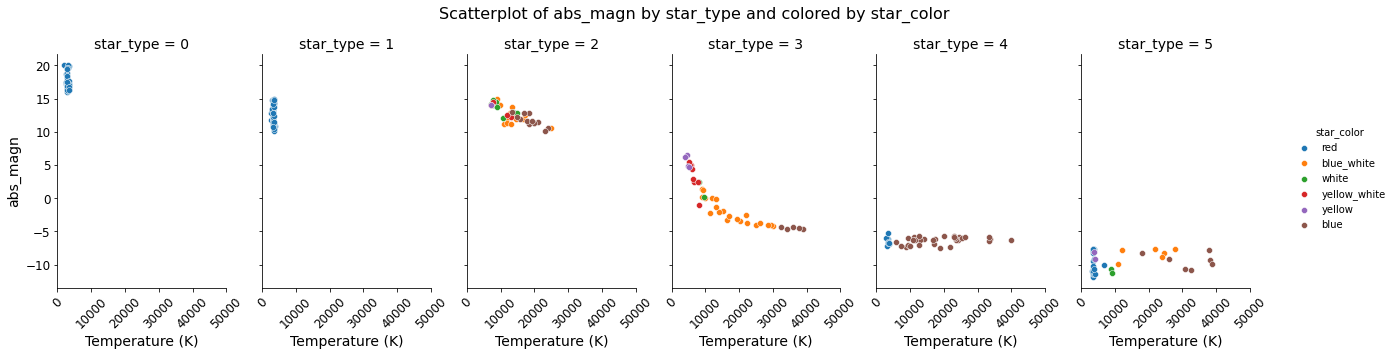

In [14]:
for col in df.columns:
    if col not in ['star_type', 'star_color']:  # Исключаем категориальные столбцы
        plt.figure(figsize=(40, 40))
        g = sns.FacetGrid(data=df, col='star_type', hue='star_color', height=5, aspect=.6)
        g.map(sns.scatterplot, 'temp_k', col)
        g.add_legend(title_fontsize=13)
        g.set_xticklabels(rotation=45)
        g.set_axis_labels('Temperature (K)', col, fontsize=14)
        g.set_titles(size=14)
        for ax in g.axes.flat:
            ax.tick_params(axis='both', labelsize=12)
        plt.suptitle(f'Scatterplot of {col} by star_type and colored by star_color', fontsize=16)
        plt.subplots_adjust(top=0.8)
        g.tight_layout()
        plt.show()

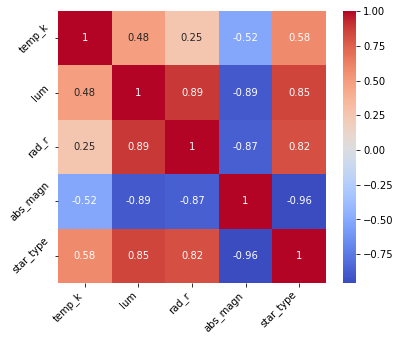

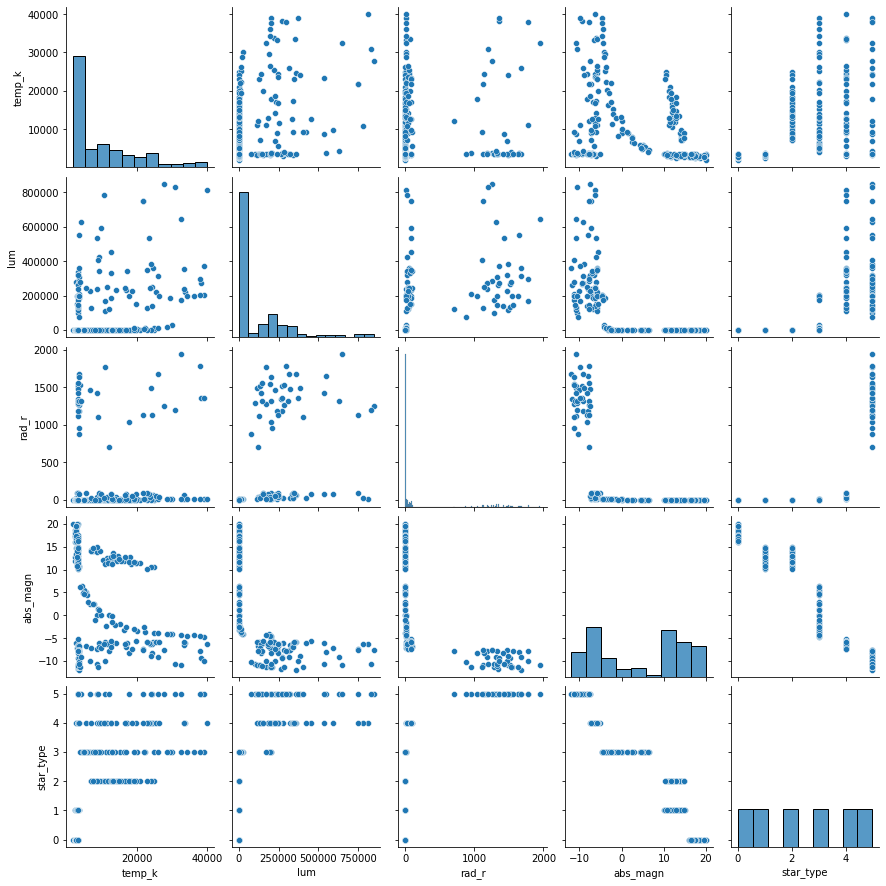

In [15]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df.select_dtypes(include=['number']).corr(method='spearman'), annot=True, cmap='coolwarm')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=45, ha='right')
sns.pairplot(df)

interval columns not set, guessing: ['temp_k', 'lum', 'rad_r', 'abs_magn', 'star_type']


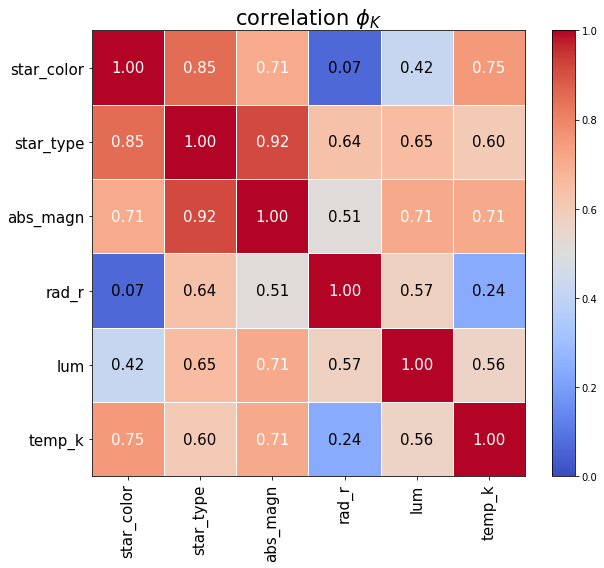

In [16]:
interval_cols = ['star_type']

phik_overview = phik_matrix(df)#, interval_cols=interval_cols)

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='coolwarm',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(9, 8)
)

### Промежуточный вывод:

В ходе корреляционного анализа выявлено отсутствие мультиколлинеарности с наличием определённой доли зависимости параметров.

В ходе исследования матрицы корреляции `phik_matrix()` утечка данных не обнаружена. Но можно заметить, что радиус звезды имеет небольшую корреляцию с целевым признаком. При обучении нейросети можно попробовать вариацию с удалением данного признака.


## Подготовка данных к построению модели

Подготовим обучающую и тестовую выборки, добавим стратификацию по типу звезды.
Также создадим выборки без параметра `rad_r`.
Проведём масштабирование количественных данных и кодирование категориальных признаков.

In [17]:
RANDOM_STATE = 42
TEST_SIZE = 0.3

df['star_index'] = df.index

X_train, X_test, y_train, y_test, train_indices, test_indices = train_test_split(
    df.drop(['temp_k', 'star_index'], axis=1), 
    df['temp_k'],
    df['star_index'],  # Сохраняем индексы звёзд
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df['star_type'],  # Используем объединенный столбец для стратификации
    shuffle=True
)

# формирование выборок без сомнительного, возможно неинформативного признака
X_train_abb = X_train.drop('rad_r', axis=1)
X_test_abb = X_test.drop('rad_r', axis=1)

ohe_columns = ['star_color']
ord_columns = ['star_type']
num_columns = ['abs_magn', 'rad_r', 'lum']
abb_num_columns = ['abs_magn', 'lum']

In [18]:
# Создание пайплайнов для pre-processing
preprocessor = ColumnTransformer(transformers=[
    ('num', PowerTransformer(method='yeo-johnson'), num_columns),  # Масштабирование количественных данных
    ('ohe', OneHotEncoder(drop='first', dtype=np.int32), ohe_columns),  # OHE для категориальных данных
    ('ord', OrdinalEncoder(), ord_columns)   # OrdinalEncoding для категориальных данных
])

preprocessor_abb = ColumnTransformer(transformers=[
    ('num', PowerTransformer(method='yeo-johnson'), abb_num_columns),  # Масштабирование количественных данных
    ('ohe', OneHotEncoder(drop='first', dtype=np.int32), ohe_columns),  # OHE для категориальных данных
    ('ord', OrdinalEncoder(), ord_columns)   # OrdinalEncoding для категориальных данных
])

# Обучение и применение трансформеров
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)
X_train_abb_transformed = preprocessor_abb.fit_transform(X_train_abb)
X_test_abb_transformed = preprocessor_abb.transform(X_test_abb)

# Преобразование y_train и y_test в массив NumPy
y_train = y_train.values
y_test = y_test.values

# Проверим размеры выходных данных
print('Размер обучающей выборки:', X_train_transformed.shape, 'Размер y_train:', y_train.shape)
print('Размер тестовой выборки:', X_test_transformed.shape, 'Размер y_test:', y_test.shape)
print('Размер сокращённой обучающей выборки:', X_train_abb_transformed.shape, 'Размер y_train:', y_train.shape)
print('Размер сокращённой тестовой выборки:', X_test_abb_transformed.shape, 'Размер y_test:', y_test.shape)

Размер обучающей выборки: (168, 9) Размер y_train: (168,)
Размер тестовой выборки: (72, 9) Размер y_test: (72,)
Размер сокращённой обучающей выборки: (168, 8) Размер y_train: (168,)
Размер сокращённой тестовой выборки: (72, 8) Размер y_test: (72,)


### Промежуточный вывод:

Данные готовы к обучению нейронной сети.

## Построение базовой нейронной сети

Создадим класс для задания архитектуры нейронной сети. Определим количество скрытых слоёв, количество нейронов на них, функции активации на скрытых и выходном слоях. 
Проведём обучение модели, по результату построим график «Факт — Прогноз», где по горизонтальной оси будут отложены условные номера звёзд, а по вертикальной — температура в Кельвинах.

In [19]:
# Настройка устройства выполнения (CPU или GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Преобразование данных в тензоры
X_train_tensor = torch.tensor(X_train_transformed, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test_transformed, dtype=torch.float32).to(device)

X_train_abb_tensor = torch.tensor(X_train_abb_transformed, dtype=torch.float32).to(device)
X_test_abb_tensor = torch.tensor(X_test_abb_transformed, dtype=torch.float32).to(device)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)  
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1).to(device) 
y_test_tensor_ = torch.tensor(y_test, dtype=torch.float32).to(device) 

In [20]:
# Определение функции для построения графиков
def fit_plot(loss, metric, abb=0):
    fig = go.Figure()
    if abb == 1:
        fig.add_trace(go.Scatter(
            x=np.array(range(len(loss)))*10,
            y=loss,
            name='Тренировка',
            line=dict(color='darkblue', width=3)
            ))
        fig.add_trace(go.Scatter(
            x=np.array(range(len(metric)))*10,
            y=metric,
            name='Тест',
            line=dict(color='crimson', width=3)
            ))
        fig.update_layout(
            width=1000,
            height=500,
            legend_orientation='h',
            title=dict(
                text='Значения функции потерь при тренировке и метрики на тесте без одного признака',
                x=.5
                ),
            xaxis_title='Эпоха',
            yaxis_title='RMSE'
            )
    else:
        fig.add_trace(go.Scatter(
            x=np.array(range(len(loss)))*10,
            y=loss,
            name='Тренировка',
            line=dict(color='darkcyan', width=3)
            ))
        fig.add_trace(go.Scatter(
            x=np.array(range(len(metric)))*10,
            y=metric,
            name='Тест',
            line=dict(color='coral', width=3)
            ))
        fig.update_layout(
            width=1000,
            height=500,
            legend_orientation='h',
            title=dict(
                text='Значения функции потерь при тренировке и метрики на тесте со всеми признаками',
                x=.5
                ),
            xaxis_title='Эпоха',
            yaxis_title='RMSE'
            )
    fig.show()

### Сети с разным количеством нейронов

Протестируем два типа сетей: с бОльшим и меньшим количеством нейронов. Также протестируем данные без одного признака. Количество скрытых слоёв одинаковое.

In [21]:
# Определение класса нейронной сети
class Net(nn.Module):
    def __init__(
        self,
        n_in_neurons,
        n_hidden_neurons_1,
        n_hidden_neurons_2,
        n_out_neurons
        ):
        super(Net, self).__init__()

        self.fc1 = nn.Linear(n_in_neurons, n_hidden_neurons_1)
        self.act1 = nn.ReLU()

        self.fc2 = nn.Linear(n_hidden_neurons_1, n_hidden_neurons_2)
        self.act2 =  nn.ReLU()

        self.fc3 = nn.Linear(n_hidden_neurons_2, n_out_neurons)

        nn.init.kaiming_normal_(self.fc1.weight, mode='fan_in')
        nn.init.normal_(self.fc1.bias, mean=.5, std=.7)
        
        nn.init.kaiming_normal_(self.fc2.weight, mode='fan_in')
        nn.init.normal_(self.fc2.bias, mean=.5, std=.7)

        nn.init.kaiming_normal_(self.fc3.weight, mode='fan_in')
        nn.init.normal_(self.fc3.bias, mean=.5, std=.7)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act1(x)

        x = self.fc2(x)
        x = self.act2(x)

        x = self.fc3(x)
        return x

In [22]:
# определение экземпляров сетей и количества нейронов
n_in_neurons = X_train_tensor.shape[1]
n_abb_in_neurons = X_train_abb_tensor.shape[1]
n_hidden_neurons_1_m = 24
n_hidden_neurons_2_m = 12
n_hidden_neurons_1_l = 18
n_hidden_neurons_2_l = 8
n_out_neurons = 1 

net_m = Net(
    n_in_neurons,
    n_hidden_neurons_1_m,
    n_hidden_neurons_2_m,
    n_out_neurons
    )
abb_net_m = Net(
    n_abb_in_neurons,
    n_hidden_neurons_1_m,
    n_hidden_neurons_2_m,
    n_out_neurons
    )
net_l = Net(
    n_in_neurons,
    n_hidden_neurons_1_l,
    n_hidden_neurons_2_l,
    n_out_neurons
    )
abb_net_l = Net(
    n_abb_in_neurons,
    n_hidden_neurons_1_l,
    n_hidden_neurons_2_l,
    n_out_neurons
    )

# определение оптимизаторов, функции потерь и количества эпох
optimizer_m = torch.optim.Adamax(net_m.parameters(), lr=5e-2)
abb_optimizer_m = torch.optim.Adamax(abb_net_m.parameters(), lr=5e-2)

optimizer_l = torch.optim.Adamax(net_l.parameters(), lr=5e-2)
abb_optimizer_l = torch.optim.Adamax(abb_net_l.parameters(), lr=5e-2)

loss = nn.MSELoss()

num_epochs = 10000

# создание списков для дальнейшего отображения графиков
train_loss_m = []
test_metric_m = []
abb_train_loss_m = []
abb_test_metric_m = []

train_loss_l = []
test_metric_l = []
abb_train_loss_l = []
abb_test_metric_l = []

In [23]:
# Определение функции для обучения нейронной сети
def fit(
    net,               # Нейронная сеть (или модель), которую нужно обучить
    optimizer,         # Оптимизатор, использующийся для обновления параметров модели
    train_loss,        # Список для хранения значений потерь на обучающей выборке
    test_metric,       # Список для хранения метрик на валидационной выборке
    patience=1,        # Количество эпох без улучшения, после которого обучение остановится
    max_delta=0,       # Максимально допустимая разница между текущей и минимальной метриками
    abb=0              # Индикатор, определяющий, использовать ли доп. преобразованные данные в обучении
):
    counter = 0                          # Счетчик эпох, когда валидационная метрика не улучшается
    min_test_metric = np.inf            # Наименьшее значение валидационной метрики, инициализируем бесконечностью

    # Цикл по эпохам
    for epoch in range(num_epochs):
        optimizer.zero_grad()             # Обнуляем градиенты модели перед новым шагом

        # Получение предсказаний на основе обучающих данных
        if abb == 1:
            preds = net.forward(X_train_abb_tensor).flatten().view(-1, 1)  
        else:
            preds = net.forward(X_train_tensor).flatten().view(-1, 1)     
        
        # Расчет потерь
        loss_value = loss(preds, y_train_tensor)  
        loss_value.backward()               

        optimizer.step()                   

        # Мониторинг потерь и метрик
        if epoch % 10 == 0 or epoch == num_epochs - 1:  
            train_loss.append(torch.sqrt(loss_value).detach())  

            net.eval()                     # Переключаем модель в режим оценки
            if abb == 1:
                test_preds = net.forward(X_test_abb_tensor).flatten().view(-1, 1)   # Используем преобразованные данные для валидации
            else:
                test_preds = net.forward(X_test_tensor).flatten().view(-1, 1)       # В противном случае используем обычные данные
            
            rmse = torch.sqrt(loss(       # Вычисляем RMSE на валидационной выборке
                test_preds,
                y_test_tensor
            )).detach()
            test_metric.append(rmse)      # Добавляем значение RMSE в список метрик валидации
            
            # Ранняя остановка
            if rmse < min_test_metric:    
                min_test_metric = rmse     
                counter = 0                 
            elif rmse >= min_test_metric:  
                counter += 1                 
            # Проверка условий для ранней остановки
            if counter >= patience or rmse - min_test_metric >= max_delta:
                break                        

In [24]:
# обучение нейронных сетей
fit(
    net_m,
    optimizer_m,
    train_loss_m,
    test_metric_m,
    10,
    50
    )
fit(
    abb_net_m,
    abb_optimizer_m,
    abb_train_loss_m,
    abb_test_metric_m,
    10,
    50,
    1
    )
fit(
    net_l,
    optimizer_l,
    train_loss_l,
    test_metric_l,
    10,
    50
    )
fit(
    abb_net_l,
    abb_optimizer_l,
    abb_train_loss_l,
    abb_test_metric_l,
    10,
    50,
    1
    )

In [25]:
# просмотр процесса обучения сетей с большим количеством нейронов
fit_plot(train_loss_m, test_metric_m)
fit_plot(abb_train_loss_m, abb_test_metric_m, 1)

In [26]:
# просмотр процесса обучения сетей с меньшим количеством нейронов
fit_plot(train_loss_l, test_metric_l)
fit_plot(abb_train_loss_l, abb_test_metric_l, 1)

In [27]:
# сравнение наилучших метрик сетей на валидации
print(
    'Наименьшая RMSE сети с большим количеством нейронов и всеми признаками —',
    np.min(test_metric_m),
    f'— на {np.argmin(test_metric_m)*10} эпохе'
    )
print(
    'Наименьшая RMSE сети с большим количеством нейронов и без одного признака —',
    np.min(abb_test_metric_m),
    f'— на {np.argmin(abb_test_metric_m)*10} эпохе'
    )
print(
    'Наименьшая RMSE сети с меньшим количеством нейронов и всеми признаками —',
    np.min(test_metric_l),
    f'— на {np.argmin(test_metric_l)*10} эпохе'
    )
print(
    'Наименьшая RMSE сети с меньшим количеством нейронов и без одного признака —',
    np.min(abb_test_metric_l),
    f'— на {np.argmin(abb_test_metric_l)*10} эпохе'
    )

Наименьшая RMSE сети с большим количеством нейронов и всеми признаками — 5799.9116 — на 580 эпохе
Наименьшая RMSE сети с большим количеством нейронов и без одного признака — 5749.4287 — на 1350 эпохе
Наименьшая RMSE сети с меньшим количеством нейронов и всеми признаками — 4530.4854 — на 2340 эпохе
Наименьшая RMSE сети с меньшим количеством нейронов и без одного признака — 5164.2056 — на 2560 эпохе


Лучший результат у сети с меньшим количеством нейронов и всеми признаками. Сравним с сетью, имеющей больше слоёв.

### Сеть с большим количеством слоёв

Протестируем  сетью, имеющую больше слоёв. Также протестируем данные без одного признака.

In [28]:
# определение класса нейронной сети с большим количеством слоёв
class NetExt(nn.Module):
    def __init__(
        self,
        n_in_neurons,
        n_hidden_neurons_1,
        n_hidden_neurons_2,
        n_hidden_neurons_3,
        n_out_neurons
        ):
        super(NetExt, self).__init__()

        self.fc1 = nn.Linear(n_in_neurons, n_hidden_neurons_1)
        self.act1 = nn.ReLU()

        self.fc2 = nn.Linear(n_hidden_neurons_1, n_hidden_neurons_2)
        self.act2 =  nn.ReLU()

        self.fc3 = nn.Linear(n_hidden_neurons_2, n_hidden_neurons_3)
        self.act3 =  nn.ReLU()

        self.fc4 = nn.Linear(n_hidden_neurons_3, n_out_neurons)

        nn.init.kaiming_normal_(self.fc1.weight, mode='fan_in')
        nn.init.normal_(self.fc1.bias, mean=.5, std=.7)
        
        nn.init.kaiming_normal_(self.fc2.weight, mode='fan_in')
        nn.init.normal_(self.fc2.bias, mean=.5, std=.7)

        nn.init.kaiming_normal_(self.fc3.weight, mode='fan_in')
        nn.init.normal_(self.fc3.bias, mean=.5, std=.7)

        nn.init.kaiming_normal_(self.fc4.weight, mode='fan_in')
        nn.init.normal_(self.fc4.bias, mean=.5, std=.7)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act1(x)

        x = self.fc2(x)
        x = self.act2(x)

        x = self.fc3(x)
        x = self.act3(x)

        x = self.fc4(x)
        return x

In [29]:
# определение экземпляров сетей и количества нейронов
n_hidden_neurons_3 = 10

net_ext = NetExt(
    n_in_neurons,
    n_hidden_neurons_1_l,
    n_hidden_neurons_2_l,
    n_hidden_neurons_3,
    n_out_neurons
    )
abb_net_ext = NetExt(
    n_abb_in_neurons,
    n_hidden_neurons_1_l,
    n_hidden_neurons_2_l,
    n_hidden_neurons_3,
    n_out_neurons
    )
# определение оптимизаторов
optimizer_ext = torch.optim.Adamax(net_ext.parameters(), lr=5e-2)
abb_optimizer_ext = torch.optim.Adamax(abb_net_ext.parameters(), lr=5e-2)

# создание списков для дальнейшего отображения графиков
train_loss_ext = []
test_metric_ext = []
abb_train_loss_ext = []
abb_test_metric_ext = []

In [30]:
# обучение нейронных сетей
fit(
    net_ext,
    optimizer_ext,
    train_loss_ext,
    test_metric_ext,
    10,
    50
    )
fit(
    abb_net_ext,
    abb_optimizer_ext,
    abb_train_loss_ext,
    abb_test_metric_ext,
    10,
    50,
    1
    )

In [31]:
# просмотр процесса обучения сетей с меньшим количеством слоёв
fit_plot(train_loss_l, test_metric_l)
fit_plot(abb_train_loss_l, abb_test_metric_l, 1)

In [32]:
# просмотр процесса обучения сетей с большим количеством слоёв
fit_plot(train_loss_ext, test_metric_ext)
fit_plot(abb_train_loss_ext, abb_test_metric_ext, 1)

In [33]:
# сравнение наилучших метрик сетей на валидации
print(
    'Наименьшая RMSE сети с меньшим количеством слоёв и всеми признаками —',
    np.min(test_metric_l),
    f'— на {np.argmin(test_metric_l)*10} эпохе'
    )
print(
    'Наименьшая RMSE сети с меньшим количеством слоёв и без одного признака —',
    np.min(abb_test_metric_l),
    f'— на {np.argmin(abb_test_metric_l)*10} эпохе'
    )
print(
    'Наименьшая RMSE сети с большим количеством слоёв и всеми признаками —',
    np.min(test_metric_ext),
    f'— на {np.argmin(test_metric_ext)*10} эпохе'
    )
print(
    'Наименьшая RMSE сети с большим количеством слоёв и без одного признака —',
    np.min(abb_test_metric_ext),
    f'— на {np.argmin(abb_test_metric_ext)*10} эпохе'
    )

Наименьшая RMSE сети с меньшим количеством слоёв и всеми признаками — 4530.4854 — на 2340 эпохе
Наименьшая RMSE сети с меньшим количеством слоёв и без одного признака — 5164.2056 — на 2560 эпохе
Наименьшая RMSE сети с большим количеством слоёв и всеми признаками — 5041.923 — на 620 эпохе
Наименьшая RMSE сети с большим количеством слоёв и без одного признака — 9411.875 — на 60 эпохе


Качество лучше у сети с меньшим количеством слоёв и всеми признаками. Далее попробуем разные функции активации.

### Сети с разными функциями активации

Создадим сеть с функцией активации ELU и сравним с лучшей сетью, обученной ранее.

In [34]:
# определение класса нейронной сети с функцией активации ELU
class NetELU(nn.Module):
    def __init__(
        self,
        n_in_neurons,
        n_hidden_neurons_1,
        n_hidden_neurons_2,
        n_out_neurons
        ):
        super(NetELU, self).__init__()

        self.fc1 = nn.Linear(n_in_neurons, n_hidden_neurons_1)
        self.act1 = nn.ELU(.001)

        self.fc2 = nn.Linear(n_hidden_neurons_1, n_hidden_neurons_2)
        self.act2 =  nn.ELU(.001)

        self.fc3 = nn.Linear(n_hidden_neurons_2, n_out_neurons)

        nn.init.kaiming_normal_(self.fc1.weight, mode='fan_in')
        nn.init.normal_(self.fc1.bias, mean=.5, std=.7)
        
        nn.init.kaiming_normal_(self.fc2.weight, mode='fan_in')
        nn.init.normal_(self.fc2.bias, mean=.5, std=.7)

        nn.init.kaiming_normal_(self.fc3.weight, mode='fan_in')
        nn.init.normal_(self.fc3.bias, mean=.5, std=.7)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act1(x)

        x = self.fc2(x)
        x = self.act2(x)

        x = self.fc3(x)
        return x

In [35]:
# определение экземпляров сетей
net_elu = NetELU(
    n_in_neurons,
    n_hidden_neurons_1_m,
    n_hidden_neurons_2_m,
    n_out_neurons
    )
abb_net_elu = NetELU(
    n_abb_in_neurons,
    n_hidden_neurons_1_m,
    n_hidden_neurons_2_m,
    n_out_neurons
    )
# определение оптимизаторов
optimizer_elu = torch.optim.Adamax(net_elu.parameters(), lr=5e-2)
abb_optimizer_elu = torch.optim.Adamax(abb_net_elu.parameters(), lr=5e-2)

# создание списков для дальнейшего отображения графиков
train_loss_elu = []
test_metric_elu = []
abb_train_loss_elu = []
abb_test_metric_elu = []

In [36]:
# обучение нейронных сетей
fit(
    net_elu,
    optimizer_elu,
    train_loss_elu,
    test_metric_elu,
    10,
    50
    )
fit(
    abb_net_elu,
    abb_optimizer_elu,
    abb_train_loss_elu,
    abb_test_metric_elu,
    10,
    50,
    1
    )

In [37]:
# просмотр процесса обучения сетей с ReLU
fit_plot(train_loss_l, test_metric_l)
fit_plot(abb_train_loss_l, abb_test_metric_l, 1)

In [38]:
# просмотр процесса обучения сетей с ELU
fit_plot(train_loss_elu, test_metric_elu)
fit_plot(abb_train_loss_elu, abb_test_metric_elu, 1)

In [39]:
# сравнение наилучших метрик сетей на валидации
print(
    'Наименьшая RMSE сети с ReLU и всеми признаками —',
    np.min(test_metric_l),
    f'— на {np.argmin(test_metric_l)*10} эпохе'
    )
print(
    'Наименьшая RMSE сети с ReLU и без одного признака —',
    np.min(abb_test_metric_l),
    f'— на {np.argmin(abb_test_metric_l)*10} эпохе'
    )
print(
    'Наименьшая RMSE сети с ELU и всеми признаками —',
    np.min(test_metric_elu),
    f'— на {np.argmin(test_metric_elu)*10} эпохе'
    )
print(
    'Наименьшая RMSE сети с ELU и без одного признака —',
    np.min(abb_test_metric_elu),
    f'— на {np.argmin(abb_test_metric_elu)*10} эпохе'
    )

Наименьшая RMSE сети с ReLU и всеми признаками — 4530.4854 — на 2340 эпохе
Наименьшая RMSE сети с ReLU и без одного признака — 5164.2056 — на 2560 эпохе
Наименьшая RMSE сети с ELU и всеми признаками — 5839.7383 — на 550 эпохе
Наименьшая RMSE сети с ELU и без одного признака — 9363.85 — на 80 эпохе


Эксперименты показали, что лучшей базовой моделью является сеть с функциями активации ReLU и всеми признаками. Её метрика MRSE составила 4530.

---

График "Факт — Прогноз", наглядно показывающий разницу между действительными и предсказанными наилучшей на данный момент конфигурацией нейросети температурами звёзд.

In [40]:
# получение предсказаний
test_predictions = net_m.forward(X_test_tensor).flatten().detach()

# построение графика
test_fig = go.Figure()
test_fig.add_trace(go.Bar(
    x=np.array(range(len(X_test_tensor))),
    y=y_test_tensor_,
    name='Факт',
    width=.9,
    marker_color='dodgerblue'
    ))
test_fig.add_trace(go.Bar(
    x=np.array(range(len(test_predictions))),
    y=test_predictions,
    name='Прогноз',
    width=.3,
    marker_color='orange'
    ))
test_fig.update_layout(
    barmode='overlay',
    width=1000,
    height=500,
    legend_orientation='h',
    title=dict(
        text='Истинные и предсказанные температуры звёзд на тестировании',
        x=.5
        ),
    xaxis_title='Номер звезды в выборке',
    yaxis_title='Температура звезды, К'
    )
test_fig.show()

### Промежуточный вывод:

По результатам рассмотрения разных архитектур нейросетей наилучшей комбинацией модели является сеть со всего двумя скрытыми слоями, небольшим количеством нейронов относительно числа признаков на входном слое и функцией активации ReLU.

По графику видно, что базовая нейросеть хорошо предсказывает небольшие значения температур, но с большими значениями допускает промахи. Среди средних значений также наблюдаются промахи, но реже. С большими значениями модель склонна занижать прогноз, со средними - завышать. Вероятно, это связано с тем, что звёзд с такой температурой мало, модель не может как следует обучиться. 

Наличие или отсутствие признака `rad_r`, даёт различный результат в зависимости от конкретной архитектуры сети — иногда качество растёт, а иногда падает. Рекомендуется при дальнейших экспериментах с моделью рассматривать оба различных набора признаков.

Метрика RMSE уже на данном этапе практически достигла требуемого порога. Попробуем ещё более улучшить качество нейросети.

## Улучшение нейронной сети

Создадим решение с перебором параметров нейросети «dropout» и «размер батча». Архитектуру нейронной сети — количество слоёв, нейронов, вид функции активации — оставим лучшую в Baseline, чтобы сравнить результат.
Проведём обучение нейронной сети, выведем метрику RMSE и график «Факт — прогноз». Метрика RMSE не должна превышать 4500.

### Добавление Dropout

In [41]:
# Определение класса нейронной сети с Dropout
class NetDp(nn.Module):
    def __init__(
        self,
        n_in_neurons,
        n_hidden_neurons_1,
        n_hidden_neurons_2,
        n_out_neurons,
        part
        ):
        super(NetDp, self).__init__()

        self.fc1 = nn.Linear(n_in_neurons, n_hidden_neurons_1)
        self.act1 = nn.ReLU()
        self.dp1 = nn.Dropout(p=part)

        self.fc2 = nn.Linear(n_hidden_neurons_1, n_hidden_neurons_2)
        self.act2 =  nn.ReLU()
        self.dp2 = nn.Dropout(p=part)

        self.fc3 = nn.Linear(n_hidden_neurons_2, n_out_neurons)

        nn.init.kaiming_normal_(self.fc1.weight, mode='fan_in')
        nn.init.normal_(self.fc1.bias, mean=.5, std=.7)
        
        nn.init.kaiming_normal_(self.fc2.weight, mode='fan_in')
        nn.init.normal_(self.fc2.bias, mean=.5, std=.7)

        nn.init.kaiming_normal_(self.fc3.weight, mode='fan_in')
        nn.init.normal_(self.fc3.bias, mean=.5, std=.7)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act1(x)
        x = self.dp1(x)

        x = self.fc2(x)
        x = self.act2(x)
        x = self.dp2(x)

        x = self.fc3(x)
        return x

In [42]:
# определение экземпляров сетей
dp_net_2 = NetDp(
    n_in_neurons,
    n_hidden_neurons_1_l,
    n_hidden_neurons_2_l,
    n_out_neurons,
    .2
    )
abb_dp_net_2 = NetDp(
    n_abb_in_neurons,
    n_hidden_neurons_1_l,
    n_hidden_neurons_2_l,
    n_out_neurons,
    .2
    )
dp_net_4 = NetDp(
    n_in_neurons,
    n_hidden_neurons_1_l,
    n_hidden_neurons_2_l,
    n_out_neurons,
    .4
    )
abb_dp_net_4 = NetDp(
    n_abb_in_neurons,
    n_hidden_neurons_1_l,
    n_hidden_neurons_2_l,
    n_out_neurons,
    .4
    )
dp_net_6 = NetDp(
    n_in_neurons,
    n_hidden_neurons_1_l,
    n_hidden_neurons_2_l,
    n_out_neurons,
    .6
    )
abb_dp_net_6 = NetDp(
    n_abb_in_neurons,
    n_hidden_neurons_1_l,
    n_hidden_neurons_2_l,
    n_out_neurons,
    .6
    )
dp_net_8 = NetDp(
    n_in_neurons,
    n_hidden_neurons_1_l,
    n_hidden_neurons_2_l,
    n_out_neurons,
    .8
    )
abb_dp_net_8 = NetDp(
    n_abb_in_neurons,
    n_hidden_neurons_1_l,
    n_hidden_neurons_2_l,
    n_out_neurons,
    .8
    )
# определение оптимизаторов
dp_optimizer_2 = torch.optim.Adamax(dp_net_2.parameters(), lr=5e-2)
abb_dp_optimizer_2 = torch.optim.Adamax(abb_dp_net_2.parameters(), lr=5e-2)
dp_optimizer_4 = torch.optim.Adamax(dp_net_4.parameters(), lr=5e-2)
abb_dp_optimizer_4 = torch.optim.Adamax(abb_dp_net_4.parameters(), lr=5e-2)
dp_optimizer_6 = torch.optim.Adamax(dp_net_6.parameters(), lr=5e-2)
abb_dp_optimizer_6 = torch.optim.Adamax(abb_dp_net_6.parameters(), lr=5e-2)
dp_optimizer_8 = torch.optim.Adamax(dp_net_8.parameters(), lr=5e-2)
abb_dp_optimizer_8 = torch.optim.Adamax(abb_dp_net_8.parameters(), lr=5e-2)

# создание списков cо значениями метрик
dp_train_loss_2 = []
dp_test_metric_2 = []
abb_dp_train_loss_2 = []
abb_dp_test_metric_2 = []
dp_train_loss_4 = []
dp_test_metric_4 = []
abb_dp_train_loss_4 = []
abb_dp_test_metric_4 = []
dp_train_loss_6 = []
dp_test_metric_6 = []
abb_dp_train_loss_6 = []
abb_dp_test_metric_6 = []
dp_train_loss_8 = []
dp_test_metric_8 = []
abb_dp_train_loss_8 = []
abb_dp_test_metric_8 = []

При использовании Dropout поднимем пороговые значения остановки обучения, так как обычно в таком случае сети требуется больше эпох для её сходимости.

In [43]:
# обучение нейронных сетей
fit(
    dp_net_2,
    dp_optimizer_2,
    dp_train_loss_2,
    dp_test_metric_2,
    20,
    100
    )
fit(
    abb_dp_net_2,
    abb_dp_optimizer_2,
    abb_dp_train_loss_2,
    abb_dp_test_metric_2,
    20,
    100,
    1
    )
fit(
    dp_net_4,
    dp_optimizer_4,
    dp_train_loss_4,
    dp_test_metric_4,
    20,
    100
    )
fit(
    abb_dp_net_4,
    abb_dp_optimizer_4,
    abb_dp_train_loss_4,
    abb_dp_test_metric_4,
    20,
    100,
    1
    )
fit(
    dp_net_6,
    dp_optimizer_6,
    dp_train_loss_6,
    dp_test_metric_6,
    20,
    100
    )
fit(
    abb_dp_net_6,
    abb_dp_optimizer_6,
    abb_dp_train_loss_6,
    abb_dp_test_metric_6,
    20,
    100,
    1
    )
fit(
    dp_net_8,
    dp_optimizer_8,
    dp_train_loss_8,
    dp_test_metric_8,
    20,
    100
    )
fit(
    abb_dp_net_8,
    abb_dp_optimizer_8,
    abb_dp_train_loss_8,
    abb_dp_test_metric_8,
    20,
    100,
    1
    )

In [44]:
# создание сравнительной таблицы показателей метрики
rmses = pd.DataFrame(
    index=['baseline'],
    columns=['all_features', 'without_one_feature']
    )
rmses.loc['baseline', 'all_features'] = np.min(test_metric_l)
rmses.loc['baseline', 'without_one_feature'] = np.min(abb_test_metric_l)

# сравнение наилучших метрик сетей на валидации
print(
    'Наименьшая RMSE сети без Dropout и со всеми признаками —',
    np.min(test_metric_l),
    f'— на {np.argmin(test_metric_l)*10} эпохе'
    )
print(
    'Наименьшая RMSE сети без Dropout и одного признака —',
    np.min(abb_test_metric_l),
    f'— на {np.argmin(abb_test_metric_l)*10} эпохе',
    '\n'
    )
print(
    'Наименьшая RMSE сети с долей Dropout 0.2 и всеми признаками —',
    np.min(dp_test_metric_2),
    f'— на {np.argmin(dp_test_metric_2)*10} эпохе'
    )
rmses.loc['dropout_0.2', 'all_features'] = np.min(dp_test_metric_2)
print(
    'Наименьшая RMSE сети с долей Dropout 0.2 и без одного признака —',
    np.min(abb_dp_test_metric_2),
    f'— на {np.argmin(abb_dp_test_metric_2)*10} эпохе',
    '\n'
    )
rmses.loc['dropout_0.2', 'without_one_feature'] = np.min(abb_dp_test_metric_2)
print(
    'Наименьшая RMSE сети с долей Dropout 0.4 и всеми признаками —',
    np.min(dp_test_metric_4),
    f'— на {np.argmin(dp_test_metric_4)*10} эпохе'
    )
rmses.loc['dropout_0.4', 'all_features'] = np.min(dp_test_metric_4)
print(
    'Наименьшая RMSE сети с долей Dropout 0.4 и без одного признака —',
    np.min(abb_dp_test_metric_4),
    f'— на {np.argmin(abb_dp_test_metric_4)*10} эпохе',
    '\n'
    )
rmses.loc['dropout_0.4', 'without_one_feature'] = np.min(abb_dp_test_metric_4)
print(
    'Наименьшая RMSE сети с долей Dropout 0.6 и всеми признаками —',
    np.min(dp_test_metric_6),
    f'— на {np.argmin(dp_test_metric_6)*10} эпохе'
    )
rmses.loc['dropout_0.6', 'all_features'] = np.min(dp_test_metric_6)
print(
    'Наименьшая RMSE сети с долей Dropout 0.6 и без одного признака —',
    np.min(abb_dp_test_metric_6),
    f'— на {np.argmin(abb_dp_test_metric_6)*10} эпохе',
    '\n'
    )
rmses.loc['dropout_0.6', 'without_one_feature'] = np.min(abb_dp_test_metric_6)
print(
    'Наименьшая RMSE сети с долей Dropout 0.8 и всеми признаками —',
    np.min(dp_test_metric_8),
    f'— на {np.argmin(dp_test_metric_8)*10} эпохе'
    )
rmses.loc['dropout_0.8', 'all_features'] = np.min(dp_test_metric_8)
print(
    'Наименьшая RMSE сети с долей Dropout 0.8 и без одного признака —',
    np.min(abb_dp_test_metric_8),
    f'— на {np.argmin(abb_dp_test_metric_8)*10} эпохе'
    )
rmses.loc['dropout_0.8', 'without_one_feature'] = np.min(abb_dp_test_metric_8)

Наименьшая RMSE сети без Dropout и со всеми признаками — 4530.4854 — на 2340 эпохе
Наименьшая RMSE сети без Dropout и одного признака — 5164.2056 — на 2560 эпохе 

Наименьшая RMSE сети с долей Dropout 0.2 и всеми признаками — 5923.5566 — на 1150 эпохе
Наименьшая RMSE сети с долей Dropout 0.2 и без одного признака — 4716.3535 — на 3190 эпохе 

Наименьшая RMSE сети с долей Dropout 0.4 и всеми признаками — 4277.9097 — на 3690 эпохе
Наименьшая RMSE сети с долей Dropout 0.4 и без одного признака — 5548.36 — на 1650 эпохе 

Наименьшая RMSE сети с долей Dropout 0.6 и всеми признаками — 5906.169 — на 770 эпохе
Наименьшая RMSE сети с долей Dropout 0.6 и без одного признака — 4731.8843 — на 3080 эпохе 

Наименьшая RMSE сети с долей Dropout 0.8 и всеми признаками — 5937.083 — на 730 эпохе
Наименьшая RMSE сети с долей Dropout 0.8 и без одного признака — 4552.6245 — на 4300 эпохе


Лучше всего себя показала сеть с долей Dropout 0.4 и всеми признаками.

### Добавление батчей

In [45]:
# Определение функции для обучения нейронной сети
def fit(
    net,               # Нейронная сеть (или модель), которую нужно обучить
    optimizer,         # Оптимизатор, использующийся для обновления параметров модели
    train_loss,        # Список для хранения значений потерь на обучающей выборке
    test_metric,      # Список для хранения метрик на валидационной выборке
    patience=1,        # Количество эпох без улучшения, после которого обучение остановится
    max_delta=0,       # Максимально допустимая разница между текущей и минимальной метриками
    abb=0              # Индикатор, определяющий, использовать ли доп. преобразованные данные в обучении
):
    counter = 0                          # Счетчик эпох, когда валидационная метрика не улучшается
    min_test_metric = np.inf            # Наименьшее значение валидационной метрики, инициализируем бесконечностью

    # Цикл по эпохам
    for epoch in range(num_epochs):
        optimizer.zero_grad()             # Обнуляем градиенты модели перед новым шагом

        # Получение предсказаний на основе обучающих данных
        if abb == 1:
            preds = net.forward(X_train_abb_tensor).flatten().view(-1, 1)  
        else:
            preds = net.forward(X_train_tensor).flatten().view(-1, 1)     
        
        # Расчет потерь
        loss_value = loss(preds, y_train_tensor)  
        loss_value.backward()               

        optimizer.step()                   

        # Мониторинг потерь и метрик
        if epoch % 10 == 0 or epoch == num_epochs - 1:  
            train_loss.append(torch.sqrt(loss_value).detach())  

            net.eval()                     # Переключаем модель в режим оценки
            if abb == 1:
                test_preds = net.forward(X_test_abb_tensor).flatten().view(-1, 1)   # Используем преобразованные данные для валидации
            else:
                test_preds = net.forward(X_test_tensor).flatten().view(-1, 1)       # В противном случае используем обычные данные
            
            rmse = torch.sqrt(loss(       # Вычисляем RMSE на валидационной выборке
                test_preds,
                y_test_tensor
            )).detach()
            test_metric.append(rmse)      # Добавляем значение RMSE в список метрик валидации
            
            # Ранняя остановка
            if rmse < min_test_metric:    
                min_test_metric = rmse     
                counter = 0                 
            elif rmse >= min_test_metric:  
                counter += 1                 
            # Проверка условий для ранней остановки
            if counter >= patience or rmse - min_test_metric >= max_delta:
                break                        

In [46]:
# определение функции для обучения нейронной сети батчами
def batches_fit(
    net,
    optimizer,
    train_loss,
    test_metric,
    patience=1,
    max_delta=0,
    batch_size=len(X_train_tensor),
    abb=0
    ):
    counter = 0
    min_test_metric = np.inf
    num_batches = ceil(len(X_train_tensor.squeeze())/batch_size)

    for epoch in range(num_epochs):
        order = np.random.permutation(len(X_train_tensor.squeeze()))
        epoch_loss_value = []

        for batch_idx in range(num_batches):
            start_index = batch_idx * batch_size
            optimizer.zero_grad()

            batch_indexes = order[start_index:start_index+batch_size]
            t_batch = y_train_tensor[batch_indexes]
            t_batch = t_batch.squeeze() 
            if abb == 1:
                f_batch = X_train_abb_tensor.squeeze()[batch_indexes]
            else:
                f_batch = X_train_tensor.squeeze()[batch_indexes]
            
            f_batch = f_batch.squeeze() 
            preds = net.forward(f_batch).flatten()

            loss_value = loss(preds, t_batch)
            epoch_loss_value.append(torch.sqrt(loss_value).detach())
            loss_value.backward()
    
            optimizer.step()

        if epoch % 10 == 0 or epoch == num_epochs - 1:
            train_loss.append(np.mean(epoch_loss_value))
            net.eval()
            if abb==1:
                test_preds = net.forward(X_test_abb_tensor.squeeze()).flatten()
            else:
                test_preds = net.forward(X_test_tensor.squeeze()).flatten()
            rmse = torch.sqrt(loss(
                test_preds,
                y_test_tensor.squeeze()
                )).detach()
            test_metric.append(rmse)
            if rmse < min_test_metric:
                min_test_metric = rmse
                counter = 0
            elif rmse >= min_test_metric:
                counter += 1
            if counter >= patience or rmse - min_test_metric >= max_delta:
                break

In [47]:
# определение экземпляров сетей
bs_net_12 = Net(
    n_in_neurons,
    n_hidden_neurons_1_l,
    n_hidden_neurons_2_l,
    n_out_neurons
    )
abb_bs_net_12 = Net(
    n_abb_in_neurons,
    n_hidden_neurons_1_l,
    n_hidden_neurons_2_l,
    n_out_neurons
    )
bs_net_24 = Net(
    n_in_neurons,
    n_hidden_neurons_1_l,
    n_hidden_neurons_2_l,
    n_out_neurons
    )
abb_bs_net_24 = Net(
    n_abb_in_neurons,
    n_hidden_neurons_1_l,
    n_hidden_neurons_2_l,
    n_out_neurons
    )
bs_net_36 = Net(
    n_in_neurons,
    n_hidden_neurons_1_l,
    n_hidden_neurons_2_l,
    n_out_neurons
    )
abb_bs_net_36 = Net(
    n_abb_in_neurons,
    n_hidden_neurons_1_l,
    n_hidden_neurons_2_l,
    n_out_neurons
    )
bs_net_48 = Net(
    n_in_neurons,
    n_hidden_neurons_1_l,
    n_hidden_neurons_2_l,
    n_out_neurons
    )
abb_bs_net_48 = Net(
    n_abb_in_neurons,
    n_hidden_neurons_1_l,
    n_hidden_neurons_2_l,
    n_out_neurons
    )
bs_net_72 = Net(
    n_in_neurons,
    n_hidden_neurons_1_l,
    n_hidden_neurons_2_l,
    n_out_neurons
    )
abb_bs_net_72 = Net(
    n_abb_in_neurons,
    n_hidden_neurons_1_l,
    n_hidden_neurons_2_l,
    n_out_neurons
    )
# определение оптимизаторов
bs_optimizer_12 = torch.optim.Adamax(bs_net_12.parameters(), lr=5e-2)
abb_bs_optimizer_12 = torch.optim.Adamax(abb_bs_net_12.parameters(), lr=5e-2)
bs_optimizer_24 = torch.optim.Adamax(bs_net_24.parameters(), lr=5e-2)
abb_bs_optimizer_24 = torch.optim.Adamax(abb_bs_net_24.parameters(), lr=5e-2)
bs_optimizer_36 = torch.optim.Adamax(bs_net_36.parameters(), lr=5e-2)
abb_bs_optimizer_36 = torch.optim.Adamax(abb_bs_net_36.parameters(), lr=5e-2)
bs_optimizer_48 = torch.optim.Adamax(bs_net_48.parameters(), lr=5e-2)
abb_bs_optimizer_48 = torch.optim.Adamax(abb_bs_net_48.parameters(), lr=5e-2)
bs_optimizer_72 = torch.optim.Adamax(bs_net_72.parameters(), lr=5e-2)
abb_bs_optimizer_72 = torch.optim.Adamax(abb_bs_net_72.parameters(), lr=5e-2)

# создание списков cо значениями метрик
bs_train_loss_12 = []
bs_test_metric_12 = []
abb_bs_train_loss_12 = []
abb_bs_test_metric_12 = []
bs_train_loss_24 = []
bs_test_metric_24 = []
abb_bs_train_loss_24 = []
abb_bs_test_metric_24 = []
bs_train_loss_36 = []
bs_test_metric_36 = []
abb_bs_train_loss_36 = []
abb_bs_test_metric_36 = []
bs_train_loss_48 = []
bs_test_metric_48 = []
abb_bs_train_loss_48 = []
abb_bs_test_metric_48 = []
bs_train_loss_72 = []
bs_test_metric_72 = []
abb_bs_train_loss_72 = []
abb_bs_test_metric_72 = []

In [48]:
# обучение нейронных сетей
batches_fit(
    bs_net_12,
    bs_optimizer_12,
    bs_train_loss_12,
    bs_test_metric_12,
    20,
    100,
    12
    )
batches_fit(
    abb_bs_net_12,
    abb_bs_optimizer_12,
    abb_bs_train_loss_12,
    abb_bs_test_metric_12,
    20,
    100,
    12,
    1
    )
batches_fit(
    bs_net_24,
    bs_optimizer_24,
    bs_train_loss_24,
    bs_test_metric_24,
    20,
    100,
    24
    )
batches_fit(
    abb_bs_net_24,
    abb_bs_optimizer_24,
    abb_bs_train_loss_24,
    abb_bs_test_metric_24,
    20,
    100,
    24,
    1
    )
batches_fit(
    bs_net_36,
    bs_optimizer_36,
    bs_train_loss_36,
    bs_test_metric_36,
    20,
    100,
    36
    )
batches_fit(
    abb_bs_net_36,
    abb_bs_optimizer_36,
    abb_bs_train_loss_36,
    abb_bs_test_metric_36,
    20,
    100,
    36,
    1
    )
batches_fit(
    bs_net_48,
    bs_optimizer_48,
    bs_train_loss_48,
    bs_test_metric_48,
    20,
    100,
    48
    )
batches_fit(
    abb_bs_net_48,
    abb_bs_optimizer_48,
    abb_bs_train_loss_48,
    abb_bs_test_metric_48,
    20,
    100,
    48,
    1
    )
batches_fit(
    bs_net_72,
    bs_optimizer_72,
    bs_train_loss_72,
    bs_test_metric_72,
    20,
    100,
    72
    )
batches_fit(
    abb_bs_net_72,
    abb_bs_optimizer_72,
    abb_bs_train_loss_72,
    abb_bs_test_metric_72,
    20,
    100,
    72,
    1
    )

In [49]:
# сравнение наилучших метрик сетей на валидации
print(
    'Наименьшая RMSE сети без батчей и со всеми признаками —',
    np.min(test_metric_l),
    f'— на {np.argmin(test_metric_l)*10} эпохе'
    )
print(
    'Наименьшая RMSE сети без батчей и одного признака —',
    np.min(abb_test_metric_l),
    f'— на {np.argmin(abb_test_metric_l)*10} эпохе',
    '\n'
    )
print(
    'Наименьшая RMSE сети с батчами размера 12 и всеми признаками —',
    np.min(bs_test_metric_12),
    f'— на {np.argmin(bs_test_metric_12)*10} эпохе'
    )
rmses.loc['n_batches_12', 'all_features'] = np.min(bs_test_metric_12)
print(
    'Наименьшая RMSE сети с батчами размера 12 и без одного признака —',
    np.min(abb_bs_test_metric_12),
    f'— на {np.argmin(abb_bs_test_metric_12)*10} эпохе',
    '\n'
    )
rmses.loc['n_batches_12', 'without_one_feature'] = \
np.min(abb_bs_test_metric_12)
print(
    'Наименьшая RMSE сети с батчами размера 24 и всеми признаками —',
    np.min(bs_test_metric_24),
    f'— на {np.argmin(bs_test_metric_24)*10} эпохе'
    )
rmses.loc['n_batches_24', 'all_features'] = np.min(bs_test_metric_24)
print(
    'Наименьшая RMSE сети с батчами размера 24 и без одного признака —',
    np.min(abb_bs_test_metric_24),
    f'— на {np.argmin(abb_bs_test_metric_24)*10} эпохе',
    '\n'
    )
rmses.loc['n_batches_24', 'without_one_feature'] = \
np.min(abb_bs_test_metric_24)
print(
    'Наименьшая RMSE сети с батчами размера 36 и всеми признаками —',
    np.min(bs_test_metric_36),
    f'— на {np.argmin(bs_test_metric_36)*10} эпохе'
    )
rmses.loc['n_batches_36', 'all_features'] = np.min(bs_test_metric_36)
print(
    'Наименьшая RMSE сети с батчами размера 36 и без одного признака —',
    np.min(abb_bs_test_metric_36),
    f'— на {np.argmin(abb_bs_test_metric_36)*10} эпохе',
    '\n'
    )
rmses.loc['n_batches_36', 'without_one_feature'] = \
np.min(abb_bs_test_metric_36)
print(
    'Наименьшая RMSE сети с батчами размера 48 и всеми признаками —',
    np.min(bs_test_metric_48),
    f'— на {np.argmin(bs_test_metric_48)*10} эпохе'
    )
rmses.loc['n_batches_48', 'all_features'] = np.min(bs_test_metric_48)
print(
    'Наименьшая RMSE сети с батчами размера 48 и без одного признака —',
    np.min(abb_bs_test_metric_48),
    f'— на {np.argmin(abb_bs_test_metric_48)*10} эпохе',
    '\n'
    )
rmses.loc['n_batches_48', 'without_one_feature'] = \
np.min(abb_bs_test_metric_48)
print(
    'Наименьшая RMSE сети с батчами размера 72 и всеми признаками —',
    np.min(bs_test_metric_72),
    f'— на {np.argmin(bs_test_metric_72)*10} эпохе'
    )
rmses.loc['n_batches_72', 'all_features'] = np.min(bs_test_metric_72)
print(
    'Наименьшая RMSE сети с батчами размера 72 и без одного признака —',
    np.min(abb_bs_test_metric_72),
    f'— на {np.argmin(abb_bs_test_metric_72)*10} эпохе'
    )
rmses.loc['n_batches_72', 'without_one_feature'] = \
np.min(abb_bs_test_metric_72)

Наименьшая RMSE сети без батчей и со всеми признаками — 4530.4854 — на 2340 эпохе
Наименьшая RMSE сети без батчей и одного признака — 5164.2056 — на 2560 эпохе 

Наименьшая RMSE сети с батчами размера 12 и всеми признаками — 5833.6235 — на 190 эпохе
Наименьшая RMSE сети с батчами размера 12 и без одного признака — 5759.45 — на 440 эпохе 

Наименьшая RMSE сети с батчами размера 24 и всеми признаками — 4474.0806 — на 1860 эпохе
Наименьшая RMSE сети с батчами размера 24 и без одного признака — 5743.928 — на 470 эпохе 

Наименьшая RMSE сети с батчами размера 36 и всеми признаками — 5859.1094 — на 520 эпохе
Наименьшая RMSE сети с батчами размера 36 и без одного признака — 5749.396 — на 650 эпохе 

Наименьшая RMSE сети с батчами размера 48 и всеми признаками — 5829.763 — на 460 эпохе
Наименьшая RMSE сети с батчами размера 48 и без одного признака — 5744.4214 — на 430 эпохе 

Наименьшая RMSE сети с батчами размера 72 и всеми признаками — 5850.9785 — на 350 эпохе
Наименьшая RMSE сети с батчами

Лучше всего себя показала сеть с долей Dropout 0.4 и всеми признаками.

Тесты выявили итоговую лучшую сеть — с использованием доли Dropout 0.4 и всеми признаками. Снова взглянем на соответствующий график "Факт — Прогноз".

In [50]:
# получение предсказаний
test_predictions = dp_net_4.forward(X_test_tensor).flatten().detach()

# построение графика
test_fig = go.Figure()
test_fig.add_trace(go.Bar(
    x=np.array(range(len(X_test_tensor))),
    y=y_test_tensor_,
    name='Факт',
    width=.9,
    marker_color='dodgerblue'
    ))
test_fig.add_trace(go.Bar(
    x=np.array(range(len(test_predictions))),
    y=test_predictions,
    name='Прогноз',
    width=.3,
    marker_color='orange'
    ))
test_fig.update_layout(
    barmode='overlay',
    width=1000,
    height=500,
    legend_orientation='h',
    title=dict(
        text='Истинные и предсказанные температуры звёзд на тесте',
        x=.5
        ),
    xaxis_title='Номер звезды в выборке',
    yaxis_title='Температура звезды, К'
    )
test_fig.show()

# оценка RMSE на тестовой выборке
print(
    'RMSE итоговой нейросети: ',
    torch.sqrt(loss(test_predictions, y_test_tensor_)).detach().numpy()
    )

RMSE итоговой нейросети:  4337.0557


### Промежуточный вывод:

C помощью Dropout удалось ещё несколько улучшить значение метрики. Использование батчей при обучении в паре случаев также дало положительный результат по сравнению с Baseline, но меньше, чем применение Dropout.

По графику видно, что улучшенная нейросеть также хорошо предсказывает небольшие значения температур и также стала точнее с  большими и средними значениями. С большими значениями модель склонна занижать прогноз, со средними - завышать. Вероятно, это связано с тем, что звёзд с такой температурой мало, модель не может как следует обучиться.


In [51]:
# получение результатов обучения
round(rmses.astype('float'), 2)

,all_features,without_one_feature
baseline,4530.49,5164.21
dropout_0.2,5923.56,4716.35
dropout_0.4,4277.91,5548.36
dropout_0.6,5906.17,4731.88
dropout_0.8,5937.08,4552.62
n_batches_12,5833.62,5759.45
n_batches_24,4474.08,5743.93
n_batches_36,5859.11,5749.40
n_batches_48,5829.76,5744.42
n_batches_72,5850.98,5879.79


## Выводы

Вам пришла задача от обсерватории «Небо на ладони»: придумать, как с помощью нейросети определять температуру на поверхности обнаруженных звёзд. Обычно для расчёта температуры учёные пользуются следующими методами:

    Закон смещения Вина.
    Закон Стефана-Больцмана.
    Спектральный анализ.

Каждый из них имеет плюсы и минусы. Обсерватория хочет внедрить технологии машинного обучения для предсказания температуры звёзд, надеясь, что этот метод будет наиболее точным и удобным.

**Описание задачи:**

В этом проекте поставлена задача разработать нейронную сеть, которая поможет предсказывать абсолютную температуру на поверхности звезды.

**Исходные данные:** 

В базе обсерватории есть характеристики уже изученных 240 звёзд:

    Относительная светимость L/Lo — светимость звезды относительно Солнца.
    Относительный радиус R/Ro — радиус звезды относительно радиуса Солнца.
    Абсолютная звёздная величина Mv — физическая величина, характеризующая блеск звезды.
    Звёздный цвет (white, red, blue, yellow, yellow-orange и др.) — цвет звезды, который определяют на основе спектрального анализа.
    Тип звезды.

**В ходе предобработки и анализа исходных данных было сделано:**

По столбцам датафрейма наблюдается одностороннее нормальное распределение данных с большим выбросом слева. По столбцу `abs_magn` видно распределение с двумя пиками. По графикам ящика с усами выделяется большое количество выбросов. Это можно объяснить несколькими предположениями:

* данных мало - выборка представлена всего лишь 240 значениями, такого количества недостаточно для формирования правильного распределения;
* типов звёзд `star_type` представлено равное количество - возможно, каждая группа своими значениями "перетягивает одеяло на себя" и из-за различности параметров представительниц каждой группы нормальное распределение не получается.

Исправлены неявные дубликаты в столбце `star_color`. Проведено исследование по типам звёзд: распределения стали намного "правильнее", количество выбросов уменьшилось.

**Корреляционный анализ данных показал:**

Изучена равномерность распределения цветовых признаков в разных группах звёзд - в каждой группе преобладают разные цвета.
Выявлено отсутствие мультиколлинеарности с наличием определённой доли зависимости параметров.
В ходе исследования матрицы корреляции `phik_matrix()` утечка данных не обнаружена. 
Замечено, что радиус звезды имеет небольшую корреляцию с целевым признаком. При обучении нейросети можно попробовать вариацию обучения с удалением данного признака.

**Данные подготовлены к обучению:**

Созданы обучающая и тестовая выборки с учётом стратификации по типу звезды. Также создана выборка без параметра `rad_r`. Проведено масштабирование количественных данных и кодирование категориального признака.

**Построена базовая нейронная сеть:**

По результатам рассмотрения разных архитектур нейросетей наилучшей комбинацией модели является сеть со всего двумя скрытыми слоями, небольшим количеством нейронов относительно числа признаков на входном слое и функцией активации ReLU.

По графику видно, что базовая нейросеть хорошо предсказывает небольшие значения температур, но с большими значениями допускает промахи. Среди средних значений также наблюдаются промахи, но реже. С большими значениями модель склонна занижать прогноз, со средними - завышать. Вероятно, это связано с тем, что звёзд с такой температурой мало, модель не может как следует обучиться. 

Наличие или отсутствие признака `rad_r`, даёт различный результат в зависимости от конкретной архитектуры сети — иногда качество растёт, а иногда падает. Рекомендуется при дальнейших экспериментах с моделью рассматривать оба различных набора признаков.

Метрика RMSE уже на данном этапе практически достигла требуемого порога.

**Улучшение нейронной сети:**

C помощью Dropout удалось ещё несколько улучшить значение метрики. Использование батчей при обучении в паре случаев также дало положительный результат по сравнению с Baseline, но меньше, чем применение Dropout.

По графику видно, что улучшенная нейросеть также хорошо предсказывает небольшие значения температур и также стала точнее с  большими и средними значениями. С большими значениями модель склонна занижать прогноз, со средними - завышать. Вероятно, это связано с тем, что звёзд с такой температурой мало, модель не может как следует обучиться.

**Для заказчика (обсерватории) можно дать несколько рекомендаций:**

* дать для создания нейросети больше данных. Особенно это касается гипергиантов, т.к. по целевому признаку этой группы наблюдается наибольший разброс, **модель не может грамотно реагировать на такие значения и занижает предсказания;**
* привести признак цвета к единой номенклатуре для внесения в базу: неявных дубликатов в общей базе может быть гораздо больше, чем в нашей выборке, лучше эту проблему доработать на этапе создания и пополнения базы.